In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import normalized_mutual_info_score

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import NearestNeighbors

from __future__ import annotations

import statsmodels.formula.api as smf

from statsmodels.stats.sandwich_covariance import cov_cluster_2groups

C:\Users\gcabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\__init__.py:169: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# Funcoes

In [2]:
# ============================================================
# GERADOR DE BASE SINTÉTICA PARA ESTUDOS CAUSAIS (PYTHON)
# ============================================================
# Objetivo:
# - ~3000 linhas
# - 1 coluna de tratamento binário (0/1)
# - 1 coluna de desfecho contínuo
# - 7 covariáveis:
#     * 3 quantitativas contínuas
#     * 2 quantitativas discretas
#     * 2 qualitativas categóricas
# - Algumas covariáveis correlacionadas (lineares e não-lineares)
# - Confundimento: algumas variáveis afetam T (tratamento) e Y (desfecho)
# - Impacto real do tratamento EXPLÍCITO para conferência posterior
#
# Estratégia do DGP (Data Generating Process):
# - Criamos covariáveis X com correlações e não-linearidades.
# - Criamos T ~ Bernoulli(p(X)) onde p(X) depende de X (confundimento).
# - Criamos desfecho com potenciais:
#       Y0 = f(X) + erro
#       Y1 = Y0 + tau(X)
#   Observado:
#       Y = Y0 + T * tau(X)
#
# Assim, o "impacto real" (ATE verdadeiro) é:
#       ATE_true = E[tau(X)]  (na amostra: mean(tau))
# ============================================================

def _sigmoid(x: np.ndarray) -> np.ndarray:
    """Função logística para mapear qualquer real -> (0,1)."""
    return 1 / (1 + np.exp(-x))

def _softmax(logits: np.ndarray) -> np.ndarray:
    """Softmax por linha: converte logits em probabilidades que somam 1."""
    z = logits - np.max(logits, axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def gerar_base_causal(n: int = 3000, seed: int = 42):
    """
    Gera um DataFrame com:
      - tratamento (0/1)
      - desfecho (contínuo)
      - 7 covariáveis (3 cont., 2 disc., 2 cat.)
    E retorna também um dicionário 'truth' com o ATE verdadeiro e a fórmula.

    Importante: NÃO retorna propensity_true nem tau por linha, nem coloca no DF.
               Mas retorna ATE verdadeiro (escalar) para conferência posterior.
    """
    rng = np.random.default_rng(seed)

    # ============================================================
    # BLOCO 1) LATENTES PARA INDUZIR CORRELAÇÃO ENTRE COVARIÁVEIS
    # ============================================================
    # z1 e z2 são correlacionados -> isso cria correlação entre variáveis derivadas
    z1 = rng.normal(0, 1, n)
    z2 = 0.65 * z1 + np.sqrt(1 - 0.65**2) * rng.normal(0, 1, n)
    z3 = rng.normal(0, 1, n)

    # ============================================================
    # BLOCO 2) COVARIÁVEIS CONTÍNUAS (3)
    # ============================================================
    # x_cont1: quase linear em z1 (com ruído)
    x_cont1 = z1 + 0.15 * z3 + rng.normal(0, 0.2, n)

    # x_cont2: correlação linear forte com x_cont1 + componente de z2
    x_cont2 = 0.85 * x_cont1 + 0.60 * z2 + rng.normal(0, 0.35, n)

    # x_cont3: mistura não-linear:
    # - termo quadrático em x_cont1 (não-linear)
    # - termo seno em x_cont2 (não-linear)
    # - + z3 e ruído
    x_cont3 = 0.55 * (x_cont1 ** 2) - 0.35 * np.sin(x_cont2) + 0.45 * z3 + rng.normal(0, 0.35, n)

    # ============================================================
    # BLOCO 3) COVARIÁVEIS DISCRETAS (2)
    # ============================================================
    # x_disc1: Poisson com taxa dependente de (x_cont1, x_cont2) de forma não-linear
    # (usamos exp(sigmoid(...)) para gerar lambda>0 e criar dependência suave)
    lam1 = np.exp(0.15 + 0.35 * _sigmoid(0.9 * x_cont1 - 0.4 * x_cont2))
    x_disc1 = rng.poisson(lam=lam1)
    x_disc1 = np.clip(x_disc1, 0, 25)

    # x_disc2: Binomial (0..10) com p dependente de x_cont2 e (x_cont1^2)
    p2 = _sigmoid(-0.2 + 0.35 * x_cont2 - 0.10 * (x_cont1 ** 2))
    x_disc2 = rng.binomial(n=10, p=np.clip(p2, 0.02, 0.98))

    # ============================================================
    # BLOCO 4) COVARIÁVEIS CATEGÓRICAS (2)
    # ============================================================
    # x_cat1 (A/B/C): gerada via softmax a partir de logits que dependem de X
    logits_cat1 = np.vstack([
        0.2 + 0.15 * x_cont2,                        # classe A (referência)
        -0.1 + 0.60 * x_cont1 - 0.10 * x_disc2,      # classe B
        0.05 - 0.50 * x_cont2 + 0.12 * x_disc1       # classe C
    ]).T
    probs_cat1 = _softmax(logits_cat1)

    cat1_idx = np.array([rng.choice(3, p=probs_cat1[i]) for i in range(n)])
    x_cat1 = np.array(["A", "B", "C"])[cat1_idx]

    # x_cat2 (low/mid/high/vip): criamos um score contínuo com não-linearidade
    # e cortamos por quantis para virar categorias.
    score = 0.75 * x_cont1 - 0.35 * np.cos(x_cont2) + 0.18 * x_disc2 + rng.normal(0, 0.35, n)
    q1, q2, q3 = np.quantile(score, [0.25, 0.65, 0.90])
    x_cat2 = np.where(score <= q1, "low",
              np.where(score <= q2, "mid",
              np.where(score <= q3, "high", "vip")))

    # Dummies úteis internamente (para construir T e Y com categorias)
    isB = (x_cat1 == "B").astype(int)
    isC = (x_cat1 == "C").astype(int)
    isVIP = (x_cat2 == "vip").astype(int)

    # ============================================================
    # BLOCO 5) TRATAMENTO (BINÁRIO) COM CONFOUNDIMENTO
    # ============================================================
    # Aqui definimos P(T=1 | X) = sigmoid(g(X))
    # g(X) depende de variáveis que também entrarão em Y -> confundidores reais.
    #
    # Confundidores principais (afetam T e Y):
    #   x_cont1, x_cont2, x_disc1, x_disc2, x_cat1, x_cat2
    #
    # Também incluímos:
    #   - sin(x_cont2) (não-linear)
    #   - interação x_cont1*x_cont2
    linprop = (
        -0.25
        + 0.75 * x_cont1
        - 0.55 * x_cont2
        + 0.18 * np.log1p(x_disc1)
        - 0.08 * x_disc2
        + 0.45 * isB
        - 0.30 * isC
        + 0.50 * isVIP
        + 0.35 * np.sin(x_cont2)
        + 0.12 * (x_cont1 * x_cont2)
    )
    p_treat = _sigmoid(linprop)
    tratamento = rng.binomial(1, p=np.clip(p_treat, 0.02, 0.98))

    # ============================================================
    # BLOCO 6) DESFECHO CONTÍNUO COM EFEITO CAUSAL EXPLÍCITO
    # ============================================================
    # 6.1) Primeiro definimos o componente "baseline" (sem tratamento): f(X)
    # Esse baseline depende (inclusive) dos mesmos confundidores usados em T.
    baseline = (
        2.0
        + 1.10 * x_cont1
        - 0.85 * x_cont2
        + 0.55 * np.sin(x_cont2)                 # não-linear
        + 0.30 * np.log1p(x_disc1)
        - 0.10 * x_disc2
        + 0.35 * (x_cat1 == "A").astype(int)
        - 0.25 * (x_cat1 == "C").astype(int)
        + 0.20 * (x_cat2 == "high").astype(int)
        + 0.40 * (x_cat2 == "vip").astype(int)
        + 0.20 * x_cont3                         # preditor forte de Y
        + 0.15 * np.maximum(x_cont1, 0) * x_cont3 # interação não-linear
    )

    # 6.2) Agora definimos o efeito do tratamento tau(X) (heterogêneo)
    # ---> Este é o "impacto real" por indivíduo, mas NÃO vamos devolvê-lo por linha.
    # ATE verdadeiro será a média de tau na amostra.
    tau = (
        1.50
        + 0.45 * isVIP
        + 0.20 * np.tanh(x_cont2)
        - 0.25 * (x_cont1 < -0.5).astype(int)
    )

    # 6.3) Potenciais:
    # Y0 = baseline + erro
    # Y1 = Y0 + tau
    erro = rng.normal(0, 1.0, n)
    y0 = baseline + erro
    y1 = y0 + tau

    # 6.4) Observado:
    # Y = Y0 se T=0
    # Y = Y1 se T=1
    desfecho = y0 + tratamento * (y1 - y0)  # que é equivalente a y0 + tratamento*tau

    # ============================================================
    # BLOCO 7) MONTA O DATAFRAME FINAL
    # ============================================================
    df = pd.DataFrame({
        "tratamento": tratamento.astype(int),
        "desfecho": desfecho.astype(float),

        # 3 contínuas
        "x_cont1": x_cont1,
        "x_cont2": x_cont2,
        "x_cont3": x_cont3,

        # 2 discretas
        "x_disc1": x_disc1.astype(int),
        "x_disc2": x_disc2.astype(int),

        # 2 categóricas
        "x_cat1": x_cat1.astype(str),
        "x_cat2": x_cat2.astype(str),
    })

    # ============================================================
    # BLOCO 8) "VERDADE" PARA CONFERÊNCIA POSTERIOR (APENAS ESCALARES)
    # ============================================================
    ate_true = float(np.mean(tau))  # ATE verdadeiro (na amostra)
    truth = {
        "seed": seed,
        "n": n,
        "ate_true": ate_true,
        "impacto_real_formula": "Y = Y0 + T * tau(X), onde Y1 = Y0 + tau(X) e ATE_true = mean(tau(X))"
    }

    return df, truth

In [3]:
# ============================================================
# 1) Funções auxiliares
# ============================================================

def _is_categorical(s: pd.Series) -> bool:
    """Detecta se a Series deve ser tratada como categórica."""
    return (
        pd.api.types.is_object_dtype(s)
        or pd.api.types.is_categorical_dtype(s)
        or pd.api.types.is_bool_dtype(s)
    )

def _safe_dropna_pair(a: pd.Series, b: pd.Series):
    """Remove linhas com NaN em qualquer uma das duas séries."""
    df2 = pd.concat([a, b], axis=1).dropna()
    return df2.iloc[:, 0].to_numpy(), df2.iloc[:, 1].to_numpy()

# ============================================================
# 2) Métrica num-num: Distance Correlation (dCor) ∈ [0,1]
#    Captura dependência geral (linear e não-linear).
# ============================================================

def _distance_correlation(x: np.ndarray, y: np.ndarray) -> float:
    """
    Distance correlation (dCor) para vetores 1D.
    Referência conceitual: distância euclidiana, dupla centralização.
    Retorna valor em [0,1]. Se variância de distância = 0, retorna 0.
    """
    x = np.asarray(x).reshape(-1)
    y = np.asarray(y).reshape(-1)
    n = len(x)
    if n < 3:
        return np.nan

    # Matrizes de distância |xi - xj|
    a = np.abs(x[:, None] - x[None, :])
    b = np.abs(y[:, None] - y[None, :])

    # Dupla centralização: A = a - a_row - a_col + a_grand
    A = a - a.mean(axis=1, keepdims=True) - a.mean(axis=0, keepdims=True) + a.mean()
    B = b - b.mean(axis=1, keepdims=True) - b.mean(axis=0, keepdims=True) + b.mean()

    dcov2 = (A * B).mean()
    dvarx = (A * A).mean()
    dvary = (B * B).mean()

    if dvarx <= 0 or dvary <= 0:
        return 0.0

    dcov = np.sqrt(max(dcov2, 0.0))
    dcor = dcov / np.sqrt(np.sqrt(dvarx) * np.sqrt(dvary))
    # Por segurança numérica, limita em [0,1]
    return float(np.clip(dcor, 0.0, 1.0))

def _dcor_with_subsample(x, y, rng, max_n=1500):
    """Calcula dCor com subamostragem para evitar custo O(n^2) grande."""
    n = len(x)
    if n <= max_n:
        return _distance_correlation(x, y)
    idx = rng.choice(n, size=max_n, replace=False)
    return _distance_correlation(x[idx], y[idx])

# ============================================================
# 3) Métrica cat-cat: Cramér's V (com correção de viés) ∈ [0,1]
# ============================================================

def _cramers_v_bias_corrected(x: pd.Series, y: pd.Series) -> float:
    """
    Cramér's V com correção de viés (recomendado em amostras finitas).
    Implementação sem scipy:
      - chi2 = Σ (O-E)^2 / E
      - phi2 = chi2/n
      - V = sqrt(phi2corr / min(kcorr-1, rcorr-1))
    """
    tab = pd.crosstab(x, y)
    n = tab.values.sum()
    if n == 0:
        return np.nan

    O = tab.values.astype(float)
    r_sum = O.sum(axis=1, keepdims=True)
    c_sum = O.sum(axis=0, keepdims=True)
    E = (r_sum @ c_sum) / n

    # Evita divisão por zero
    mask = E > 0
    chi2 = np.sum(((O - E) ** 2)[mask] / E[mask])

    phi2 = chi2 / n
    r, k = tab.shape

    # Correção de viés (Bergsma & Wicher-style)
    phi2corr = max(0.0, phi2 - ((k - 1) * (r - 1)) / (n - 1)) if n > 1 else 0.0
    rcorr = r - ((r - 1) ** 2) / (n - 1) if n > 1 else r
    kcorr = k - ((k - 1) ** 2) / (n - 1) if n > 1 else k

    denom = min(kcorr - 1, rcorr - 1)
    if denom <= 0:
        return 0.0

    v = np.sqrt(phi2corr / denom)
    return float(np.clip(v, 0.0, 1.0))

# ============================================================
# 4) Métrica cat-num: Eta (Correlation Ratio) ∈ [0,1]
# ============================================================

def _eta_correlation_ratio(categories: pd.Series, values: pd.Series) -> float:
    """
    Eta (η) = sqrt(SS_between / SS_total).
    Interpretação: quanto da variância de Y é explicada pela categoria.
    Retorna em [0,1].
    """
    df2 = pd.DataFrame({"cat": categories, "val": values}).dropna()
    if len(df2) < 3:
        return np.nan

    y = df2["val"].astype(float).to_numpy()
    cat = df2["cat"].astype("category")

    y_mean = y.mean()
    ss_total = np.sum((y - y_mean) ** 2)
    if ss_total <= 0:
        return 0.0

    ss_between = 0.0
    for level in cat.cat.categories:
        y_g = df2.loc[cat == level, "val"].to_numpy()
        if len(y_g) == 0:
            continue
        ss_between += len(y_g) * (y_g.mean() - y_mean) ** 2

    eta2 = ss_between / ss_total
    eta = np.sqrt(max(eta2, 0.0))
    return float(np.clip(eta, 0.0, 1.0))

# ============================================================
# 5) Painel geral de dependências (uma matriz 0..1)
# ============================================================

def painel_geral_dependencias(
    df: pd.DataFrame,
    cols: list | None = None,
    max_n_dcor: int = 1500,
    seed: int = 42,
    top_k: int = 20,
    plot: bool = True,
):
    """
    Cria um "painel geral" (matriz) com associação em [0,1] para todas as variáveis:
      - num-num: dCor
      - cat-cat: Cramér's V
      - cat-num: Eta (η)

    Também retorna:
      - pearson (matriz linear para numéricas)
      - tabela top pares por associação
      - tabela de 'não-linearidade provável' (dCor alto, Pearson baixo)
      - matriz de métodos usados por par (para auditoria)
    """
    if cols is None:
        cols = df.columns.tolist()

    rng = np.random.default_rng(seed)

    # Detecta tipo de cada coluna
    col_is_cat = {c: _is_categorical(df[c]) for c in cols}
    num_cols = [c for c in cols if not col_is_cat[c]]

    # Pearson (apenas numéricas) para comparação
    pearson = df[num_cols].corr(method="pearson") if len(num_cols) else pd.DataFrame()

    # Matrizes finais
    assoc = pd.DataFrame(np.eye(len(cols)), index=cols, columns=cols, dtype=float)
    method = pd.DataFrame("", index=cols, columns=cols, dtype=object)

    # Preenche diagonal
    for c in cols:
        method.loc[c, c] = "diag"

    # Calcula pares
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            a, b = cols[i], cols[j]
            a_cat, b_cat = col_is_cat[a], col_is_cat[b]

            if (not a_cat) and (not b_cat):
                # num-num -> dCor
                x, y = _safe_dropna_pair(df[a], df[b])
                val = _dcor_with_subsample(x, y, rng=rng, max_n=max_n_dcor)
                met = "dcor(num-num)"

            elif a_cat and b_cat:
                # cat-cat -> Cramér's V
                val = _cramers_v_bias_corrected(df[a], df[b])
                met = "cramers_v(cat-cat)"

            else:
                # cat-num -> Eta
                if a_cat and (not b_cat):
                    val = _eta_correlation_ratio(df[a], df[b])
                    met = "eta(cat-num)"
                else:
                    val = _eta_correlation_ratio(df[b], df[a])
                    met = "eta(cat-num)"

            assoc.loc[a, b] = val
            assoc.loc[b, a] = val
            method.loc[a, b] = met
            method.loc[b, a] = met

    # ------------------------------------------------------------
    # Top pares por associação (exclui diagonal)
    # ------------------------------------------------------------
    pairs = []
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            a, b = cols[i], cols[j]
            pairs.append({
                "var_1": a,
                "var_2": b,
                "assoc_0a1": assoc.loc[a, b],
                "metodo": method.loc[a, b],
            })
    top_pairs = pd.DataFrame(pairs).sort_values("assoc_0a1", ascending=False).head(top_k)

    # ------------------------------------------------------------
    # Sinais de não-linearidade em num-num:
    # dCor alto e |Pearson| baixo
    # ------------------------------------------------------------
    nonlinear_flags = []
    if len(num_cols) >= 2:
        for i in range(len(num_cols)):
            for j in range(i + 1, len(num_cols)):
                a, b = num_cols[i], num_cols[j]
                dcor_val = assoc.loc[a, b]  # aqui é dCor (porque num-num)
                pear_val = pearson.loc[a, b]
                nonlinear_flags.append({
                    "var_1": a,
                    "var_2": b,
                    "dcor": dcor_val,
                    "abs_pearson": abs(pear_val),
                    "gap(dcor - |pearson|)": dcor_val - abs(pear_val),
                })
    nonlinear_df = (pd.DataFrame(nonlinear_flags)
                    .sort_values("gap(dcor - |pearson|)", ascending=False)
                    .head(top_k)) if nonlinear_flags else pd.DataFrame()

    # ------------------------------------------------------------
    # Prints amigáveis
    # ------------------------------------------------------------
    print("\n=== Painel geral de dependências (0..1) ===")
    print("num-num: dCor | cat-cat: Cramér's V | cat-num: Eta (η)\n")

    print(f"Top {top_k} pares mais associados (painel geral):")
    print(top_pairs.to_string(index=False))

    if not nonlinear_df.empty:
        print(f"\nTop {top_k} candidatos a relação NÃO-LINEAR (dCor alto, Pearson baixo):")
        print(nonlinear_df.to_string(index=False))

In [4]:
# ============================================================
# SMD (Standardized Mean Difference) - Balanceamento
# ============================================================
# Para variáveis numéricas:
#   SMD = (mean_T - mean_C) / sqrt((sd_T^2 + sd_C^2)/2)
#
# Para dummies (0/1), incluindo níveis de variáveis categóricas:
#   SMD = (p_T - p_C) / sqrt((p_T*(1-p_T) + p_C*(1-p_C))/2)
#
# Regra prática muito usada:
#   |SMD| < 0.10  => bom equilíbrio (ideal)
#   0.10 a 0.20   => leve/moderado desequilíbrio
#   > 0.20        => desequilíbrio relevante
# ============================================================

def _smd_numeric(x_t, x_c) -> float:
    """SMD para variável numérica (contínua ou discreta)."""
    mt = np.mean(x_t)
    mc = np.mean(x_c)
    st = np.std(x_t, ddof=1)
    sc = np.std(x_c, ddof=1)
    pooled = np.sqrt((st**2 + sc**2) / 2)

    # Evita divisão por zero (variável constante dentro dos grupos)
    if pooled == 0 or np.isnan(pooled):
        return np.nan
    return (mt - mc) / pooled

def _smd_binary(p_t, p_c) -> float:
    """SMD para variável binária (0/1), usando proporções."""
    vt = p_t * (1 - p_t)
    vc = p_c * (1 - p_c)
    pooled = np.sqrt((vt + vc) / 2)

    if pooled == 0 or np.isnan(pooled):
        return np.nan
    return (p_t - p_c) / pooled

def calcular_smd_por_variavel(
    df: pd.DataFrame,
    treat_col: str = "tratamento",
    cols: list | None = None,
    threshold: float = 0.10,
    ordenar_por_abs: bool = True,
    plot: bool = True,
):
    """
    Calcula SMD por variável.
    - Numéricas: uma linha por variável.
    - Categóricas: uma linha por nível (dummy), ex: x_cat1=B.

    Retorna:
      DataFrame com SMDs + imprime resumo e (opcional) gera gráfico.
    """
    if cols is None:
        # pega tudo exceto tratamento e desfecho (se existir)
        cols = [c for c in df.columns if c not in {treat_col, "desfecho"}]

    # separa grupos
    treated = df[df[treat_col] == 1].copy()
    control = df[df[treat_col] == 0].copy()

    rows = []

    for col in cols:
        s = df[col]

        # Detecta categórica (object/category/bool tratado como categórica)
        is_categorical = (
            pd.api.types.is_object_dtype(s)
            or pd.api.types.is_categorical_dtype(s)
            or pd.api.types.is_bool_dtype(s)
        )

        if not is_categorical:
            # trata como numérica (contínua ou discreta)
            x_t = treated[col].dropna().to_numpy()
            x_c = control[col].dropna().to_numpy()

            smd = _smd_numeric(x_t, x_c)

            rows.append({
                "variavel": col,
                "nivel": None,
                "tipo": "numerica",
                "smd": smd,
                "abs_smd": np.abs(smd) if pd.notnull(smd) else np.nan,
                "media_trat": np.mean(x_t) if len(x_t) else np.nan,
                "media_ctrl": np.mean(x_c) if len(x_c) else np.nan,
            })

        else:
            # categórica -> cria dummies por nível e calcula SMD por dummy
            dummies = pd.get_dummies(df[col], prefix=col, dummy_na=False)

            for dcol in dummies.columns:
                p_t = dummies.loc[df[treat_col] == 1, dcol].mean()
                p_c = dummies.loc[df[treat_col] == 0, dcol].mean()

                smd = _smd_binary(p_t, p_c)

                rows.append({
                    "variavel": col,
                    "nivel": dcol.replace(col + "_", ""),  # só o nível
                    "tipo": "categorica_dummy",
                    "smd": smd,
                    "abs_smd": np.abs(smd) if pd.notnull(smd) else np.nan,
                    "prop_trat": p_t,
                    "prop_ctrl": p_c,
                })

    smd_df = pd.DataFrame(rows)

    if ordenar_por_abs:
        smd_df = smd_df.sort_values("abs_smd", ascending=False)

    # Marca balanceado / não balanceado conforme threshold
    smd_df["balanceado(|SMD|<limiar)"] = smd_df["abs_smd"] < threshold

    # ------------------------------------------------------------
    # Impressão amigável
    # ------------------------------------------------------------
    print(f"\nLimiar de equilíbrio usado: |SMD| < {threshold:.2f}")
    print("Interpretação prática: quanto mais perto de 0, mais equilibrado.\n")

    # Mostra um resumo rápido: quais estão mais desbalanceadas
    top = smd_df.head(15).copy()
    print("Top 15 maiores |SMD| (mais desbalanceadas):")
    cols_show = ["variavel", "nivel", "tipo", "smd", "abs_smd", "balanceado(|SMD|<limiar)"]
    print(top[cols_show].to_string(index=False))

    # ------------------------------------------------------------
    # Gráfico (opcional): |SMD| por variável/nível com linha do limiar
    # ------------------------------------------------------------
    if plot:
        plot_df = smd_df.dropna(subset=["abs_smd"]).copy()

        # Cria um rótulo único por linha (variável ou variável=nível)
        plot_df["label"] = np.where(
            plot_df["nivel"].isna(),
            plot_df["variavel"],
            plot_df["variavel"] + "=" + plot_df["nivel"].astype(str)
        )

        # Para o gráfico não ficar gigante, você pode limitar (ajuste aqui se quiser)
        max_itens = min(30, len(plot_df))
        plot_df = plot_df.head(max_itens).iloc[::-1]  # inverte para o maior ficar no topo no barh

        plt.figure(figsize=(10, max(6, 0.28 * max_itens)))
        plt.barh(plot_df["label"], plot_df["abs_smd"])
        plt.axvline(threshold, linewidth=2)  # linha do limiar "ideal"
        plt.xlabel("|SMD|")
        plt.title(f"Balanceamento por SMD (Top {max_itens} maiores) — limiar = {threshold:.2f}")
        plt.tight_layout()
        plt.show()

    return smd_df

In [5]:
# ============================================================
# 1) Estimar Propensity Score (com cross-val / out-of-fold)
# ============================================================
def estimar_propensity_score(
    df: pd.DataFrame,
    treat_col: str = "tratamento",
    covariates: list | None = None,
    n_splits: int = 5,
    seed: int = 42,
):
    """
    Retorna df com coluna 'propensity_score' (predição out-of-fold).
    """
    if covariates is None:
        # padrão para o seu dataset sintético
        covariates = ["x_cont1", "x_cont2", "x_cont3", "x_disc1", "x_disc2", "x_cat1", "x_cat2"]

    X = df[covariates].copy()
    y = df[treat_col].astype(int).copy()

    # Detecta tipos
    cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    num_cols = [c for c in X.columns if c not in cat_cols]

    # Pré-processamento: numéricas padronizadas + categóricas one-hot
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ],
        remainder="drop"
    )

    # Modelo de PS: regressão logística com regularização (estável e padrão)
    model = LogisticRegression(max_iter=2000, solver="lbfgs")

    pipe = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", model),
    ])

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    # Probabilidade out-of-fold de T=1
    ps = cross_val_predict(pipe, X, y, cv=cv, method="predict_proba")[:, 1]

    out = df.copy()
    out["propensity_score"] = np.clip(ps, 1e-6, 1 - 1e-6)  # evita 0/1 exatos (útil p/ pesos)
    return out


# ============================================================
# 2) Visualizar sobreposição + métricas de common support
# ============================================================
def avaliar_sobreposicao(
    df_ps: pd.DataFrame,
    treat_col: str = "tratamento",
    ps_col: str = "propensity_score",
    bins: int = 30,
):
    """
    Mostra gráficos e imprime métricas de sobreposição.
    """
    ps_t = df_ps.loc[df_ps[treat_col] == 1, ps_col].to_numpy()
    ps_c = df_ps.loc[df_ps[treat_col] == 0, ps_col].to_numpy()

    # Suporte comum (common support) básico:
    # intervalo onde EXISTE ps nos dois grupos
    lower = max(ps_t.min(), ps_c.min())
    upper = min(ps_t.max(), ps_c.max())

    frac_t_out = np.mean((ps_t < lower) | (ps_t > upper))
    frac_c_out = np.mean((ps_c < lower) | (ps_c > upper))

    print("\n=== Propensity Score: resumo e suporte comum ===")
    print(f"Treated   PS min/max: {ps_t.min():.4f} / {ps_t.max():.4f}")
    print(f"Control   PS min/max: {ps_c.min():.4f} / {ps_c.max():.4f}")
    print(f"Common support interval: [{lower:.4f}, {upper:.4f}]")
    print(f"% tratados fora do common support: {100*frac_t_out:.2f}%")
    print(f"% controles fora do common support: {100*frac_c_out:.2f}%")

    # ------------------------------------------------------------
    # Plot 1: histogramas (densidade) sobrepostos
    # ------------------------------------------------------------
    plt.figure(figsize=(10, 5))
    plt.hist(ps_c, bins=bins, density=True, alpha=0.5, label="Controle (T=0)")
    plt.hist(ps_t, bins=bins, density=True, alpha=0.5, label="Tratado (T=1)")
    plt.axvline(lower, linewidth=2)
    plt.axvline(upper, linewidth=2)
    plt.title("Sobreposição do Propensity Score (histogramas)")
    plt.xlabel("Propensity Score")
    plt.ylabel("Densidade")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Plot 2: boxplot rápido por grupo
    # ------------------------------------------------------------
    plt.figure(figsize=(8, 4))
    plt.boxplot([ps_c, ps_t], labels=["Controle (T=0)", "Tratado (T=1)"])
    plt.title("Distribuição do Propensity Score por grupo")
    plt.ylabel("Propensity Score")
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Métrica opcional: "overlap coefficient" por interseção de histogramas
    # (0 = nenhuma sobreposição, 1 = sobreposição perfeita)
    # ------------------------------------------------------------
    hist_t, edges = np.histogram(ps_t, bins=bins, range=(0, 1), density=True)
    hist_c, _     = np.histogram(ps_c, bins=bins, range=(0, 1), density=True)
    bin_width = edges[1] - edges[0]
    overlap_coeff = np.sum(np.minimum(hist_t, hist_c)) * bin_width

    print(f"\nOverlap coefficient (interseção de densidades por hist): {overlap_coeff:.3f} (0..1)")

    return {
        "common_support": (lower, upper),
        "pct_out_support_treated": frac_t_out,
        "pct_out_support_control": frac_c_out,
        "overlap_coeff": overlap_coeff
    }

In [6]:
def aplicar_trimming_overlap_ps(
    df_ps: pd.DataFrame,
    treat_col: str = "tratamento",
    ps_col: str = "propensity_score",
    ps_range: tuple[float, float] = (0.1, 0.9),
    intersect_common_support: bool = True,
    verbose: bool = True,
):
    """
    Trimming por overlap "estrito" no propensity score.

    Mantém unidades com PS dentro de ps_range (ex.: [0.1, 0.9]),
    e opcionalmente intersecta com o common support empírico (min/max por grupo).

    Interpretação (importante):
    - Você passa a estimar o efeito na subpopulação com overlap (região "bem suportada").
    - Isso pode remover tratados com PS muito alto e controles com PS muito baixo.
    """

    lo, hi = ps_range
    if not (0 < lo < hi < 1):
        raise ValueError(f"ps_range inválido: {ps_range}. Esperado 0 < lo < hi < 1.")

    ps_t = df_ps.loc[df_ps[treat_col] == 1, ps_col].to_numpy(dtype=float)
    ps_c = df_ps.loc[df_ps[treat_col] == 0, ps_col].to_numpy(dtype=float)

    if ps_t.size == 0 or ps_c.size == 0:
        raise ValueError("Não há observações em um dos grupos (tratado/controle).")

    # Common support empírico (min/max por grupo)
    cs_lo = max(np.min(ps_t), np.min(ps_c))
    cs_hi = min(np.max(ps_t), np.max(ps_c))

    final_lo, final_hi = lo, hi
    if intersect_common_support:
        final_lo = max(final_lo, cs_lo)
        final_hi = min(final_hi, cs_hi)

    if final_lo >= final_hi:
        raise ValueError(
            "Interseção vazia entre ps_range e common support.\n"
            f"ps_range={ps_range}, common_support=[{cs_lo:.4f}, {cs_hi:.4f}] -> "
            f"final=[{final_lo:.4f}, {final_hi:.4f}]"
        )

    mask = (df_ps[ps_col] >= final_lo) & (df_ps[ps_col] <= final_hi)
    df_trim = df_ps.loc[mask].copy()

    if verbose:
        n0 = len(df_ps)
        n1 = len(df_trim)

        # Remoções por grupo
        before_t = (df_ps[treat_col] == 1).sum()
        before_c = (df_ps[treat_col] == 0).sum()
        after_t  = (df_trim[treat_col] == 1).sum()
        after_c  = (df_trim[treat_col] == 0).sum()

        print("\n=== Trimming por Overlap (PS range) ===")
        print(f"ps_range alvo: [{lo:.4f}, {hi:.4f}]")
        if intersect_common_support:
            print(f"common support empírico: [{cs_lo:.4f}, {cs_hi:.4f}]")
        print(f"intervalo final mantido: [{final_lo:.4f}, {final_hi:.4f}]")

        print(f"Antes: {n0} | Depois: {n1} | Removidas: {n0 - n1} ({100*(1 - n1/n0):.2f}%)")
        print(f"Tratados: {before_t} -> {after_t} (removidos {before_t - after_t})")
        print(f"Controles: {before_c} -> {after_c} (removidos {before_c - after_c})")

        # Alerta útil (quando você está mudando “muito” a população)
        frac_drop_t = (before_t - after_t) / max(before_t, 1)
        if frac_drop_t > 0.10:
            print("ALERTA: >10% dos TRATADOS foram removidos. "
                  "Seu efeito passa a ser para a população com overlap (não o ATT original).")

    info = {
        "ps_range_target": (lo, hi),
        "common_support": (float(cs_lo), float(cs_hi)),
        "final_range": (float(final_lo), float(final_hi)),
        "intersect_common_support": bool(intersect_common_support),
    }
    return df_trim, info

In [7]:
def _get_groups_by_strata(df: pd.DataFrame, strata_cols: list[str]) -> dict:
    """
    Retorna dict: key (tuple ou scalar) -> Index (labels) daquele estrato.
    Mantém NA como grupo (dropna=False) quando suportado.
    Fallback compatível com pandas antigos.
    """
    # tenta caminho "oficial"
    try:
        return df.groupby(strata_cols, dropna=False).groups
    except TypeError:
        # fallback: cria chaves com NA explícito para não "sumir" do groupby
        tmp = df[strata_cols].copy()
        for c in strata_cols:
            tmp[c] = tmp[c].astype(object)
        tmp = tmp.where(tmp.notna(), "<NA>")
        keys = list(map(tuple, tmp.to_numpy()))
        key_ser = pd.Series(keys, index=df.index)
        return key_ser.groupby(key_ser).groups


def propensity_score_matching(
    df_ps: pd.DataFrame,
    treat_col: str = "tratamento",
    ps_col: str = "propensity_score",
    k: int = 1,
    with_replacement: bool = True,
    use_logit: bool = True,
    caliper: float | None = 0.2,
    caliper_scale: str = "sd",  # 'sd' (clássico) ou 'absolute'
    require_full_match: bool = True,  # relevante p/ sem reposição
    seed: int = 42,
    strata_cols: list[str] | tuple[str, ...] | None = None,  # <<< NOVO (liga/desliga)
):
    """
    Faz PSM por Nearest Neighbor em 1:k.

    NOVO (estratos / exact matching):
      - strata_cols=None (padrão): matching livre (comportamento atual)
      - strata_cols=[...]: matching só dentro do mesmo estrato (mesma combinação dessas colunas)

    Retorna:
      pairs_df: (treated_id, control_id, distance, rank)
      info: dicionário com estatísticas do matching (+ métricas de estratos se ativado)
    """
    if k < 1:
        raise ValueError("k deve ser >= 1")

    rng = np.random.default_rng(seed)

    treated = df_ps[df_ps[treat_col] == 1].copy()
    control = df_ps[df_ps[treat_col] == 0].copy()

    if treated.empty or control.empty:
        raise ValueError("Precisa haver tratados e controles no dataset.")

    # valida strata_cols
    if strata_cols is not None:
        if isinstance(strata_cols, (str, bytes)):
            raise TypeError("strata_cols deve ser lista/tupla de colunas, não uma string única.")
        strata_cols = list(strata_cols)
        missing = [c for c in strata_cols if c not in df_ps.columns]
        if missing:
            raise ValueError(f"Colunas em strata_cols não existem no df_ps: {missing}")
        if len(strata_cols) == 0:
            strata_cols = None  # tratar como desligado

    # Score usado no matching: PS ou logit(PS)
    st_all = treated[ps_col].to_numpy()
    sc_all = control[ps_col].to_numpy()
    if use_logit:
        st_all = _logit(st_all)
        sc_all = _logit(sc_all)

    # Caliper absoluto no espaço do score (baseado nos tratados como no seu código original)
    caliper_abs = _compute_caliper_abs(st_all, caliper=caliper, caliper_scale=caliper_scale)

    treated_ids_all = treated.index.to_numpy()
    control_ids_all = control.index.to_numpy()

    pairs: list[dict] = []

    # ============================================================
    # Particionamento por estratos (ou "estrato único" se desligado)
    # ============================================================
    if strata_cols is None:
        strata_plan = [(None, np.arange(len(treated_ids_all)), np.arange(len(control_ids_all)))]
        strata_stats = None
    else:
        # mapeia index label -> posição no array st_all/sc_all
        treated_pos = pd.Series(np.arange(len(treated)), index=treated.index)
        control_pos = pd.Series(np.arange(len(control)), index=control.index)

        g_t = _get_groups_by_strata(treated, strata_cols)
        g_c = _get_groups_by_strata(control, strata_cols)

        keys_t = set(g_t.keys())
        keys_c = set(g_c.keys())
        keys_overlap = keys_t & keys_c

        treated_with_any_control = 0
        treated_with_control_ge_k = 0
        treated_no_control_same_stratum = 0
        treated_controls_lt_k_same_stratum = 0

        strata_plan = []
        for key, t_idx_labels in g_t.items():
            n_t_in = len(t_idx_labels)
            c_idx_labels = g_c.get(key, None)

            if c_idx_labels is None or len(c_idx_labels) == 0:
                treated_no_control_same_stratum += n_t_in
                continue

            treated_with_any_control += n_t_in
            if len(c_idx_labels) >= k:
                treated_with_control_ge_k += n_t_in
            else:
                treated_controls_lt_k_same_stratum += n_t_in

            t_pos = treated_pos.loc[list(t_idx_labels)].to_numpy(dtype=int)
            c_pos = control_pos.loc[list(c_idx_labels)].to_numpy(dtype=int)

            strata_plan.append((key, t_pos, c_pos))

        strata_stats = {
            "strata_cols": strata_cols,
            "n_strata_treated": len(keys_t),
            "n_strata_control": len(keys_c),
            "n_strata_overlap": len(keys_overlap),
            "treated_no_control_same_stratum": int(treated_no_control_same_stratum),
            "treated_controls_lt_k_same_stratum": int(treated_controls_lt_k_same_stratum),
            # “cobertura” útil p/ diagnosticar se estratos estão “apertados” demais
            "strata_coverage_rate_any_control": float(treated_with_any_control / len(treated_ids_all)),
            "strata_coverage_rate_control_ge_k": float(treated_with_control_ge_k / len(treated_ids_all)),
        }

    # ============================================================
    # Funções internas: matching por bloco (estrato)
    # ============================================================
    def _match_with_replacement(t_pos: np.ndarray, c_pos: np.ndarray):
        nonlocal pairs

        t_ids = treated_ids_all[t_pos]
        c_ids = control_ids_all[c_pos]
        st = st_all[t_pos]
        sc = sc_all[c_pos]

        n_c = len(c_ids)
        if n_c == 0:
            return

        # se exige k e o estrato não tem controles suficientes, não casa ninguém nesse estrato
        if require_full_match and (n_c < k):
            return

        k_eff = min(k, n_c)  # necessário para o kneighbors não explodir

        nn = NearestNeighbors(n_neighbors=k_eff, metric="euclidean")
        nn.fit(sc.reshape(-1, 1))
        distances, idxs = nn.kneighbors(st.reshape(-1, 1), n_neighbors=k_eff, return_distance=True)

        for i, tid in enumerate(t_ids):
            kept_rows = []
            for r in range(k_eff):
                cid = c_ids[idxs[i, r]]
                dist = float(distances[i, r])

                if (caliper_abs is not None) and (dist > caliper_abs):
                    continue

                kept_rows.append({
                    "treated_id": tid,
                    "control_id": cid,
                    "distance": dist,
                    "rank": len(kept_rows) + 1
                })

                if len(kept_rows) == k:
                    break

            # regra “exigente”: só aceita se conseguiu k
            if require_full_match and (len(kept_rows) < k):
                continue

            # se não exige full, aceita se tiver pelo menos 1
            if (not require_full_match) and (len(kept_rows) == 0):
                continue

            pairs.extend(kept_rows)

    def _match_without_replacement(t_pos: np.ndarray, c_pos: np.ndarray):
        nonlocal pairs

        t_ids = treated_ids_all[t_pos]
        c_ids = control_ids_all[c_pos]
        st = st_all[t_pos]
        sc = sc_all[c_pos]

        n_c = len(c_ids)
        if n_c == 0:
            return

        # se exige k e o estrato não tem controles suficientes, ninguém nesse estrato consegue k
        if require_full_match and (n_c < k):
            return

        # mesma heurística do seu código: ordenar tratados por score
        order = np.argsort(st)
        t_ids_ord = t_ids[order]
        st_ord = st[order]

        available = np.ones(n_c, dtype=bool)

        for tid, score_t in zip(t_ids_ord, st_ord):
            idx_av = np.flatnonzero(available)
            if idx_av.size == 0:
                break

            diffs = np.abs(sc[idx_av] - score_t)

            kk = min(k, len(diffs))
            best_local = np.argpartition(diffs, kk - 1)[:kk]
            best_local = best_local[np.argsort(diffs[best_local])]

            chosen = []
            for pos in best_local:
                dist = float(diffs[pos])
                if (caliper_abs is not None) and (dist > caliper_abs):
                    continue
                chosen.append((idx_av[pos], dist))
                if len(chosen) == k:
                    break

            if require_full_match and (len(chosen) < k):
                continue
            if (not require_full_match) and (len(chosen) == 0):
                continue

            for rank, (idx_global, dist) in enumerate(chosen, start=1):
                cid = c_ids[idx_global]
                pairs.append({
                    "treated_id": tid,
                    "control_id": cid,
                    "distance": dist,
                    "rank": rank
                })
                available[idx_global] = False

    # ============================================================
    # Executa matching por estrato (ou tudo junto se strata_cols=None)
    # ============================================================
    for _, t_pos, c_pos in strata_plan:
        if with_replacement:
            _match_with_replacement(t_pos, c_pos)
        else:
            _match_without_replacement(t_pos, c_pos)

    pairs_df = pd.DataFrame(pairs)

    # ============================================================
    # Estatísticas resumidas
    # ============================================================
    n_t = len(treated_ids_all)
    n_c = len(control_ids_all)

    n_t_matched = pairs_df["treated_id"].nunique() if not pairs_df.empty else 0
    avg_neighbors = (pairs_df.groupby("treated_id").size().mean() if n_t_matched > 0 else 0.0)

    info = {
        "n_treated": int(n_t),
        "n_control": int(n_c),
        "k_requested": int(k),
        "with_replacement": bool(with_replacement),
        "use_logit": bool(use_logit),
        "caliper_abs": caliper_abs,
        "require_full_match": bool(require_full_match),
        "treated_matched": int(n_t_matched),
        "treated_match_rate": float(n_t_matched / n_t) if n_t else 0.0,
        "avg_neighbors_kept": float(avg_neighbors),
        "total_pairs": int(len(pairs_df)),
    }

    if strata_stats is not None:
        info.update(strata_stats)

    return pairs_df, info

def construir_base_matched_com_pesos_ATT(
    df: pd.DataFrame,
    pairs_df: pd.DataFrame,
    treat_col: str = "tratamento",
    k: int = 1,
    normalize_by_treated: bool = False,  # <<< NOVO
) -> pd.DataFrame:
    """
    Constrói base matched empilhada com pesos para ATT:
      - tratados: peso = 1
      - controles:
          * normalize_by_treated=False (padrão antigo):
              peso = (#vezes_usado) / k
              (bom quando cada tratado tem exatamente k vizinhos)
          * normalize_by_treated=True (recomendado se require_full_match=False):
              para cada tratado i com m_i vizinhos, cada controle recebe 1/m_i
              e o peso final do controle é a soma desses aportes.
    """
    if pairs_df is None or pairs_df.empty:
        raise ValueError("pairs_df vazio. Caliper pode estar muito restritivo ou overlap insuficiente.")

    treated_ids = pairs_df["treated_id"].unique()
    df_t = df.loc[treated_ids].copy()
    df_t["peso"] = 1.0

    if not normalize_by_treated:
        control_counts = pairs_df["control_id"].value_counts()
        df_c = df.loc[control_counts.index].copy()
        df_c["peso"] = control_counts.values.astype(float) / float(k)
    else:
        # cada tratado distribui 1 igualmente entre seus vizinhos
        m_i = pairs_df.groupby("treated_id")["control_id"].size()
        tmp = pairs_df[["treated_id", "control_id"]].copy()
        tmp["pair_w"] = tmp["treated_id"].map(m_i).astype(float)
        tmp["pair_w"] = 1.0 / tmp["pair_w"]

        ctrl_w = tmp.groupby("control_id")["pair_w"].sum()
        df_c = df.loc[ctrl_w.index].copy()
        df_c["peso"] = ctrl_w.values.astype(float)

    return pd.concat([df_t, df_c], axis=0)

In [8]:
# ============================================================
# Helpers: média/variância ponderadas
# ============================================================

def wmean(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    return np.sum(w * x) / np.sum(w)

def wvar(x, w):
    # variância ponderada (tipo "population")
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    mu = wmean(x, w)
    return np.sum(w * (x - mu) ** 2) / np.sum(w)

def logit(p):
    p = np.clip(np.asarray(p, dtype=float), 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

# ============================================================
# SMD ponderado (numéricas e dummies)
# ============================================================

def smd_weighted(x_t, w_t, x_c, w_c):
    mt = wmean(x_t, w_t)
    mc = wmean(x_c, w_c)
    vt = wvar(x_t, w_t)
    vc = wvar(x_c, w_c)
    pooled = np.sqrt((vt + vc) / 2)
    if pooled == 0 or np.isnan(pooled):
        return np.nan
    return (mt - mc) / pooled

def compute_balance_metrics(
    df: pd.DataFrame,
    treat_col: str,
    covariates: list,
    weights_col: str | None = None,
    smd_threshold: float = 0.10
):
    """
    Retorna:
      - tabela de SMD por variável (categóricas viram dummies por nível)
      - ASAM (média |SMD|)
      - max |SMD|
      - % abaixo do limiar
    """
    if weights_col is None:
        w = np.ones(len(df), dtype=float)
    else:
        w = df[weights_col].to_numpy(dtype=float)

    tmask = df[treat_col].to_numpy(dtype=int) == 1
    cmask = ~tmask

    rows = []
    for col in covariates:
        s = df[col]
        is_cat = (
            pd.api.types.is_object_dtype(s)
            or pd.api.types.is_categorical_dtype(s)
            or pd.api.types.is_bool_dtype(s)
        )

        if not is_cat:
            x = pd.to_numeric(s, errors="coerce").to_numpy()
            smd = smd_weighted(x[tmask], w[tmask], x[cmask], w[cmask])
            rows.append({"feature": col, "level": None, "smd": smd, "abs_smd": abs(smd)})

        else:
            dummies = pd.get_dummies(s, prefix=col, dummy_na=False)
            for dcol in dummies.columns:
                x = dummies[dcol].to_numpy(dtype=float)
                smd = smd_weighted(x[tmask], w[tmask], x[cmask], w[cmask])
                level = dcol.replace(col + "_", "")
                rows.append({"feature": col, "level": level, "smd": smd, "abs_smd": abs(smd)})

    smd_df = pd.DataFrame(rows).dropna(subset=["abs_smd"])
    asam = float(smd_df["abs_smd"].mean()) if len(smd_df) else np.nan
    max_abs = float(smd_df["abs_smd"].max()) if len(smd_df) else np.nan
    pct_ok = float((smd_df["abs_smd"] < smd_threshold).mean()) if len(smd_df) else np.nan

    return smd_df.sort_values("abs_smd", ascending=False), asam, max_abs, pct_ok

# ============================================================
# Construir base matched com pesos (ATT) a partir dos pares
# controles: peso = (#vezes_usado)/k
# tratados: peso = 1
# ============================================================

def build_matched_att(df_ps, pairs_df, treat_col="tratamento", k=1):
    treated_ids = pairs_df["treated_id"].unique()
    df_t = df_ps.loc[treated_ids].copy()
    df_t["peso"] = 1.0

    counts = pairs_df["control_id"].value_counts()
    df_c = df_ps.loc[counts.index].copy()
    df_c["peso"] = counts.values.astype(float) / float(k)

    return pd.concat([df_t, df_c], axis=0)

# ============================================================
# Rubin's B e R no logit(PS) com pesos
# ============================================================

def rubin_BR(df_matched, treat_col="tratamento", ps_col="propensity_score", wcol="peso"):
    tmask = df_matched[treat_col].to_numpy(dtype=int) == 1
    w = df_matched[wcol].to_numpy(dtype=float)

    lp = logit(df_matched[ps_col].to_numpy(dtype=float))

    mt = wmean(lp[tmask], w[tmask])
    mc = wmean(lp[~tmask], w[~tmask])
    vt = wvar(lp[tmask], w[tmask])
    vc = wvar(lp[~tmask], w[~tmask])

    pooled_sd = np.sqrt((vt + vc) / 2) if (vt + vc) > 0 else np.nan
    B = 100 * abs(mt - mc) / pooled_sd if pooled_sd and not np.isnan(pooled_sd) else np.nan
    R = vt / vc if (vc and vc > 0) else np.nan
    return float(B), float(R)

# ============================================================
# ESS dos controles
# ============================================================

def ess_controls(df_matched, treat_col="tratamento", wcol="peso"):
    ctrl = df_matched[df_matched[treat_col] == 0]
    w = ctrl[wcol].to_numpy(dtype=float)
    if len(w) == 0:
        return np.nan
    return float((w.sum() ** 2) / np.sum(w ** 2))

# ============================================================
# Avaliar uma configuração (k, reposição)
# ============================================================

def evaluate_matching_config(
    df_ps,
    pairs_df,
    info,
    covariates,
    treat_col="tratamento",
    ps_col="propensity_score",
    smd_threshold=0.10,
    k=1,
):
    if pairs_df.empty:
        return {
            "k": k,
            "with_replacement": info.get("with_replacement"),
            "with_strata": bool(info.get("strata_cols") is not None),
            "strata_cols": info.get("strata_cols"),
            "treated_match_rate": 0.0,
            "asam": np.inf,
            "max_abs_smd": np.inf,
            "pct_smd_ok": 0.0,
            "ess_controls": 0.0,
            "rubin_B": np.inf,
            "rubin_R": np.nan,
            "mean_distance": np.nan,
            "unique_controls": 0,
            "total_pairs": 0,
        }

    df_matched = build_matched_att(df_ps, pairs_df, treat_col=treat_col, k=k)

    smd_df, asam, max_abs, pct_ok = compute_balance_metrics(
        df_matched, treat_col=treat_col, covariates=covariates, weights_col="peso", smd_threshold=smd_threshold
    )

    B, R = rubin_BR(df_matched, treat_col=treat_col, ps_col=ps_col, wcol="peso")
    ess = ess_controls(df_matched, treat_col=treat_col, wcol="peso")

    out = {
        "k": k,
        "with_replacement": bool(info.get("with_replacement")),
        "with_strata": bool(info.get("strata_cols") is not None),
        "strata_cols": info.get("strata_cols"),
        "treated_match_rate": float(info.get("treated_match_rate", np.nan)),
        "treated_matched": int(info.get("treated_matched", 0)),
        "total_pairs": int(info.get("total_pairs", len(pairs_df))),
        "unique_controls": int(pairs_df["control_id"].nunique()),
        "mean_distance": float(pairs_df["distance"].mean()),
        "asam": float(asam),
        "max_abs_smd": float(max_abs),
        "pct_smd_ok": float(pct_ok),
        "ess_controls": float(ess),
        "rubin_B": float(B),
        "rubin_R": float(R),
    }

    # adiciona diagnósticos de estratos se vierem no info
    for extra_key in [
        "n_strata_treated", "n_strata_control", "n_strata_overlap",
        "treated_no_control_same_stratum",
        "treated_controls_lt_k_same_stratum",
        "strata_coverage_rate_any_control",
        "strata_coverage_rate_control_ge_k",
    ]:
        if extra_key in info:
            out[extra_key] = info[extra_key]

    return out

# ============================================================
# Utilitários (Código 2): logit + caliper abs + estratos
# ============================================================

def _logit(p: np.ndarray) -> np.ndarray:
    """logit(p) = log(p/(1-p)) com clipping para evitar infinito."""
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

def _compute_caliper_abs(scores_t: np.ndarray, caliper: float | None, caliper_scale: str) -> float | None:
    """
    Converte caliper relativo em caliper absoluto no espaço do score usado.
    - caliper=None => sem caliper
    - caliper_scale='sd' => caliper_abs = caliper * sd(scores_t)
    - caliper_scale='absolute' => caliper_abs = caliper
    """
    if caliper is None:
        return None
    if caliper_scale == "sd":
        sd = np.std(scores_t, ddof=1)
        return float(caliper * sd)
    if caliper_scale == "absolute":
        return float(caliper)
    raise ValueError("caliper_scale deve ser 'sd' ou 'absolute'")

def _get_groups_by_strata(df: pd.DataFrame, strata_cols: list[str]) -> dict:
    """
    Retorna dict: key -> Index labels daquele estrato.
    Mantém NA como grupo (dropna=False) quando suportado.
    """
    try:
        return df.groupby(strata_cols, dropna=False).groups
    except TypeError:
        tmp = df[strata_cols].copy()
        for c in strata_cols:
            tmp[c] = tmp[c].astype(object)
        tmp = tmp.where(tmp.notna(), "<NA>")
        keys = list(map(tuple, tmp.to_numpy()))
        key_ser = pd.Series(keys, index=df.index)
        return key_ser.groupby(key_ser).groups

# ============================================================
# Matching principal: com/sem reposição e k vizinhos + estratos
# ============================================================

def propensity_score_matching(
    df_ps: pd.DataFrame,
    treat_col: str = "tratamento",
    ps_col: str = "propensity_score",
    k: int = 1,
    with_replacement: bool = True,
    use_logit: bool = True,
    caliper: float | None = 0.2,
    caliper_scale: str = "sd",  # 'sd' (clássico) ou 'absolute'
    require_full_match: bool = True,  # relevante p/ sem reposição
    seed: int = 42,
    strata_cols: list[str] | tuple[str, ...] | None = None,  # <<< opcional (liga/desliga)
):
    """
    Faz PSM por Nearest Neighbor em 1:k.

    Estratos (exact matching por qualitativas):
      - strata_cols=None (padrão): matching livre (comportamento atual)
      - strata_cols=[...]: matching só dentro do mesmo estrato

    Retorna:
      pairs_df: (treated_id, control_id, distance, rank)
      info: dicionário com estatísticas do matching (+ métricas de estratos se ativado)
    """
    if k < 1:
        raise ValueError("k deve ser >= 1")

    rng = np.random.default_rng(seed)

    treated = df_ps[df_ps[treat_col] == 1].copy()
    control = df_ps[df_ps[treat_col] == 0].copy()

    if treated.empty or control.empty:
        raise ValueError("Precisa haver tratados e controles no dataset.")

    # valida strata_cols
    if strata_cols is not None:
        if isinstance(strata_cols, (str, bytes)):
            raise TypeError("strata_cols deve ser lista/tupla de colunas, não string única.")
        strata_cols = list(strata_cols)
        missing = [c for c in strata_cols if c not in df_ps.columns]
        if missing:
            raise ValueError(f"Colunas em strata_cols não existem no df_ps: {missing}")
        if len(strata_cols) == 0:
            strata_cols = None

    # Score usado no matching: PS ou logit(PS)
    st_all = treated[ps_col].to_numpy()
    sc_all = control[ps_col].to_numpy()
    if use_logit:
        st_all = _logit(st_all)
        sc_all = _logit(sc_all)

    # Caliper absoluto no espaço do score
    caliper_abs = _compute_caliper_abs(st_all, caliper=caliper, caliper_scale=caliper_scale)

    treated_ids_all = treated.index.to_numpy()
    control_ids_all = control.index.to_numpy()

    pairs: list[dict] = []

    # ------------------------------------------------------------
    # Particiona por estratos (ou estrato único se desligado)
    # ------------------------------------------------------------
    if strata_cols is None:
        strata_plan = [(None, np.arange(len(treated_ids_all)), np.arange(len(control_ids_all)))]
        strata_stats = None
        strata_cols_info = None
    else:
        treated_pos = pd.Series(np.arange(len(treated)), index=treated.index)
        control_pos = pd.Series(np.arange(len(control)), index=control.index)

        g_t = _get_groups_by_strata(treated, strata_cols)
        g_c = _get_groups_by_strata(control, strata_cols)

        keys_t = set(g_t.keys())
        keys_c = set(g_c.keys())
        keys_overlap = keys_t & keys_c

        treated_with_any_control = 0
        treated_with_control_ge_k = 0
        treated_no_control_same_stratum = 0
        treated_controls_lt_k_same_stratum = 0

        strata_plan = []
        for key, t_idx_labels in g_t.items():
            n_t_in = len(t_idx_labels)
            c_idx_labels = g_c.get(key, None)

            if c_idx_labels is None or len(c_idx_labels) == 0:
                treated_no_control_same_stratum += n_t_in
                continue

            treated_with_any_control += n_t_in
            if len(c_idx_labels) >= k:
                treated_with_control_ge_k += n_t_in
            else:
                treated_controls_lt_k_same_stratum += n_t_in

            t_pos = treated_pos.loc[list(t_idx_labels)].to_numpy(dtype=int)
            c_pos = control_pos.loc[list(c_idx_labels)].to_numpy(dtype=int)
            strata_plan.append((key, t_pos, c_pos))

        strata_stats = {
            "strata_cols": ",".join(map(str, strata_cols)),
            "n_strata_treated": int(len(keys_t)),
            "n_strata_control": int(len(keys_c)),
            "n_strata_overlap": int(len(keys_overlap)),
            "treated_no_control_same_stratum": int(treated_no_control_same_stratum),
            "treated_controls_lt_k_same_stratum": int(treated_controls_lt_k_same_stratum),
            "strata_coverage_rate_any_control": float(treated_with_any_control / len(treated_ids_all)),
            "strata_coverage_rate_control_ge_k": float(treated_with_control_ge_k / len(treated_ids_all)),
        }
        strata_cols_info = strata_stats["strata_cols"]

    # ------------------------------------------------------------
    # Matching por bloco (estrato)
    # ------------------------------------------------------------
    def _match_with_replacement(t_pos: np.ndarray, c_pos: np.ndarray):
        nonlocal pairs

        t_ids = treated_ids_all[t_pos]
        c_ids = control_ids_all[c_pos]
        st = st_all[t_pos]
        sc = sc_all[c_pos]

        n_c = len(c_ids)
        if n_c == 0:
            return

        if require_full_match and (n_c < k):
            return

        k_eff = min(k, n_c)

        nn = NearestNeighbors(n_neighbors=k_eff, metric="euclidean")
        nn.fit(sc.reshape(-1, 1))
        distances, idxs = nn.kneighbors(st.reshape(-1, 1), n_neighbors=k_eff, return_distance=True)

        for i, tid in enumerate(t_ids):
            kept_rows = []
            for r in range(k_eff):
                cid = c_ids[idxs[i, r]]
                dist = float(distances[i, r])

                if (caliper_abs is not None) and (dist > caliper_abs):
                    continue

                kept_rows.append({
                    "treated_id": tid,
                    "control_id": cid,
                    "distance": dist,
                    "rank": len(kept_rows) + 1
                })
                if len(kept_rows) == k:
                    break

            if require_full_match and (len(kept_rows) < k):
                continue
            if (not require_full_match) and (len(kept_rows) == 0):
                continue

            pairs.extend(kept_rows)

    def _match_without_replacement(t_pos: np.ndarray, c_pos: np.ndarray):
        nonlocal pairs

        t_ids = treated_ids_all[t_pos]
        c_ids = control_ids_all[c_pos]
        st = st_all[t_pos]
        sc = sc_all[c_pos]

        n_c = len(c_ids)
        if n_c == 0:
            return

        if require_full_match and (n_c < k):
            return

        order = np.argsort(st)
        t_ids_ord = t_ids[order]
        st_ord = st[order]

        available = np.ones(n_c, dtype=bool)

        for tid, score_t in zip(t_ids_ord, st_ord):
            idx_av = np.flatnonzero(available)
            if idx_av.size == 0:
                break

            diffs = np.abs(sc[idx_av] - score_t)

            kk = min(k, len(diffs))
            best_local = np.argpartition(diffs, kk - 1)[:kk]
            best_local = best_local[np.argsort(diffs[best_local])]

            chosen = []
            for pos in best_local:
                dist = float(diffs[pos])
                if (caliper_abs is not None) and (dist > caliper_abs):
                    continue
                chosen.append((idx_av[pos], dist))
                if len(chosen) == k:
                    break

            if require_full_match and (len(chosen) < k):
                continue
            if (not require_full_match) and (len(chosen) == 0):
                continue

            for rank, (idx_global, dist) in enumerate(chosen, start=1):
                cid = c_ids[idx_global]
                pairs.append({
                    "treated_id": tid,
                    "control_id": cid,
                    "distance": dist,
                    "rank": rank
                })
                available[idx_global] = False

    # executa por estrato (ou tudo junto)
    for _, t_pos, c_pos in strata_plan:
        if with_replacement:
            _match_with_replacement(t_pos, c_pos)
        else:
            _match_without_replacement(t_pos, c_pos)

    pairs_df = pd.DataFrame(pairs)

    # ------------------------------------------------------------
    # Estatísticas
    # ------------------------------------------------------------
    n_t = len(treated_ids_all)
    n_c = len(control_ids_all)

    n_t_matched = pairs_df["treated_id"].nunique() if not pairs_df.empty else 0
    avg_neighbors = (pairs_df.groupby("treated_id").size().mean() if n_t_matched > 0 else 0.0)

    info = {
        "n_treated": int(n_t),
        "n_control": int(n_c),
        "k_requested": int(k),
        "with_replacement": bool(with_replacement),
        "use_logit": bool(use_logit),
        "caliper_abs": caliper_abs,
        "require_full_match": bool(require_full_match),
        "treated_matched": int(n_t_matched),
        "treated_match_rate": float(n_t_matched / n_t) if n_t else 0.0,
        "avg_neighbors_kept": float(avg_neighbors),
        "total_pairs": int(len(pairs_df)),
        "strata_cols": strata_cols_info,  # None se desligado
    }
    if strata_stats is not None:
        info.update(strata_stats)

    return pairs_df, info

# ============================================================
# Grid search: testa configs e monta "painel"
# (com comparação: sem estratos vs com estratos)
# ============================================================

def matching_grid_search(
    df_ps,
    covariates,
    ks=(1,2,3,5),
    replacement_options=(True, False),
    smd_threshold=0.10,
    strata_cols=None,                 # <<< lista de colunas ou None
    compare_strata=True,              # <<< se True e strata_cols != None, roda (None e strata_cols)
    **matching_kwargs
):
    """
    matching_kwargs vai para propensity_score_matching(...),
    ex.: caliper=0.2, use_logit=True, require_full_match=True

    Estratos:
      - strata_cols=None => roda só sem estrato
      - strata_cols=[...] e compare_strata=True => roda duas versões: sem estrato e com estrato
      - strata_cols=[...] e compare_strata=False => roda só com estrato
    """
    results = []

    if strata_cols is None:
        strata_modes = [None]
    else:
        if compare_strata:
            strata_modes = [None, list(strata_cols)]
        else:
            strata_modes = [list(strata_cols)]

    for s_cols in strata_modes:
        for rep in replacement_options:
            for k in ks:
                pairs_df, info = propensity_score_matching(
                    df_ps,
                    k=k,
                    with_replacement=rep,
                    strata_cols=s_cols,
                    **matching_kwargs
                )

                res = evaluate_matching_config(
                    df_ps,
                    pairs_df,
                    info,
                    covariates=covariates,
                    smd_threshold=smd_threshold,
                    k=k
                )

                results.append(res)

    panel = pd.DataFrame(results)

    panel = panel.sort_values(
        by=["max_abs_smd", "asam", "treated_match_rate", "ess_controls", "mean_distance"],
        ascending=[True, True, False, False, True]
    )

    return panel

# ============================================================
# Plot rápido: 4 linhas por gráfico
# (com/sem reposição) x (com/sem estratos)
# ============================================================

def plot_tradeoffs(panel: pd.DataFrame, smd_threshold=0.10):
    required = {"with_replacement", "k", "with_strata"}
    missing = required - set(panel.columns)
    if missing:
        raise ValueError(
            f"panel não tem colunas necessárias: {missing}. "
            "Rode matching_grid_search com strata_cols e compare_strata apropriados."
        )

    style = {
        False: {"linestyle": "-",  "marker": "o", "label_suffix": "sem estrato"},
        True:  {"linestyle": "--", "marker": "s", "label_suffix": "com estrato"},
    }

    for metric, title in [
        ("max_abs_smd", "Max |SMD| pós-matching (menor é melhor)"),
        ("asam", "ASAM (média |SMD|) (menor é melhor)"),
        ("treated_match_rate", "% tratados pareados (maior é melhor)"),
        ("ess_controls", "ESS dos controles (maior é melhor)"),
        ("mean_distance", "Distância média (menor é melhor)")
    ]:
        plt.figure(figsize=(9, 4))

        for rep in [True, False]:
            for with_strata in [False, True]:
                sub = panel[
                    (panel["with_replacement"] == rep) &
                    (panel["with_strata"] == with_strata)
                ].sort_values("k")

                if sub.empty:
                    continue

                rep_label = "com reposição" if rep else "sem reposição"
                suf = style[with_strata]["label_suffix"]
                lbl = f"{rep_label} | {suf}"

                plt.plot(
                    sub["k"],
                    sub[metric],
                    label=lbl,
                    linestyle=style[with_strata]["linestyle"],
                    marker=style[with_strata]["marker"],
                )

        if metric == "max_abs_smd":
            plt.axhline(smd_threshold, linewidth=2)

        plt.title(title)
        plt.xlabel("k (nº vizinhos)")
        plt.legend()
        plt.tight_layout()
        plt.show()

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def wmean(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    return np.sum(w * x) / np.sum(w)

def wvar(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    mu = wmean(x, w)
    return np.sum(w * (x - mu)**2) / np.sum(w)

def smd_weighted(x_t, w_t, x_c, w_c):
    mt = wmean(x_t, w_t)
    mc = wmean(x_c, w_c)
    vt = wvar(x_t, w_t)
    vc = wvar(x_c, w_c)
    pooled = np.sqrt((vt + vc) / 2)
    if pooled == 0 or np.isnan(pooled):
        return np.nan
    return (mt - mc) / pooled

def smd_table_matched(df_matched, treat_col="tratamento", weight_col="peso",
                      covariates=None, threshold=0.10):
    if covariates is None:
        covariates = ["x_cont1","x_cont2","x_cont3","x_disc1","x_disc2","x_cat1","x_cat2"]

    tmask = df_matched[treat_col].astype(int).to_numpy() == 1
    w = df_matched[weight_col].to_numpy(dtype=float)

    rows = []
    for col in covariates:
        s = df_matched[col]
        is_cat = (
            pd.api.types.is_object_dtype(s)
            or pd.api.types.is_categorical_dtype(s)
            or pd.api.types.is_bool_dtype(s)
            or pd.api.types.is_bool_dtype(s)
        )

        if not is_cat:
            x = pd.to_numeric(s, errors="coerce").to_numpy(dtype=float)
            smd = smd_weighted(x[tmask], w[tmask], x[~tmask], w[~tmask])
            rows.append({"variavel": col, "nivel": None, "smd": smd, "abs_smd": abs(smd)})
        else:
            dummies = pd.get_dummies(s, prefix=col, dummy_na=False)
            for dcol in dummies.columns:
                x = dummies[dcol].to_numpy(dtype=float)
                smd = smd_weighted(x[tmask], w[tmask], x[~tmask], w[~tmask])
                rows.append({"variavel": col, "nivel": dcol.replace(col + "_", ""),
                             "smd": smd, "abs_smd": abs(smd)})

    out = pd.DataFrame(rows).dropna(subset=["abs_smd"]).sort_values("abs_smd", ascending=False)
    out["ok(|SMD|<limiar)"] = out["abs_smd"] < threshold
    return out

def love_plot(smd_df, threshold=0.10, max_items=30):
    plot_df = smd_df.copy()
    plot_df["label"] = np.where(plot_df["nivel"].isna(),
                                plot_df["variavel"],
                                plot_df["variavel"] + "=" + plot_df["nivel"].astype(str))
    plot_df = plot_df.head(max_items).iloc[::-1]

    plt.figure(figsize=(10, max(6, 0.28 * len(plot_df))))
    plt.barh(plot_df["label"], plot_df["abs_smd"])
    plt.axvline(threshold, linewidth=2)
    plt.xlabel("|SMD|")
    plt.title(f"Love Plot — Top {len(plot_df)} maiores |SMD| (pós-matching)")
    plt.tight_layout()
    plt.show()

In [10]:
def _ensure_id_column(df: pd.DataFrame, id_col: str) -> pd.DataFrame:
    """Se id_col não existir, cria a partir do índice."""
    out = df.copy()
    if id_col not in out.columns:
        out[id_col] = out.index
    return out

def att_from_pairs(
    df_matched: pd.DataFrame,
    pairs: pd.DataFrame,
    *,
    id_col: str = "id",                 # id no df_matched (cria do index se não existir)
    outcome_col: str = "desfecho",
    treated_id_col: str = "treated_id",
    control_id_col: str = "control_id",
    distance_col: str = "distance",
    weight_scheme: str = "equal",       # "equal" | "inv_distance" | "exp_distance"
    eps: float = 1e-12,
):
    """
    Calcula ATT = mean_i [ Y_t(i) - sum_j w_ij Y_c(ij) ] para tratados i.
    Retorna: att, diffs (d_i por tratado), diag_pairs (pairs com y_t, y_c, w).
    """
    df2 = _ensure_id_column(df_matched, id_col)

    # outcomes para merge (tratados e controles)
    y = df2[[id_col, outcome_col]].copy()
    treated_y = y.rename(columns={id_col: treated_id_col, outcome_col: "y_t"})
    control_y = y.rename(columns={id_col: control_id_col, outcome_col: "y_c"})

    p = pairs.copy()
    p = p.merge(treated_y, on=treated_id_col, how="left")
    p = p.merge(control_y, on=control_id_col, how="left")

    # checagens úteis
    if p["y_t"].isna().any():
        missing = p.loc[p["y_t"].isna(), treated_id_col].unique()[:10]
        raise ValueError(f"treated_id sem match no df_matched. Exemplos: {missing}")
    if p["y_c"].isna().any():
        missing = p.loc[p["y_c"].isna(), control_id_col].unique()[:10]
        raise ValueError(f"control_id sem match no df_matched. Exemplos: {missing}")

    # pesos dentro de cada tratado
    if weight_scheme == "equal":
        w_raw = np.ones(len(p), dtype=float)
    elif weight_scheme == "inv_distance":
        w_raw = 1.0 / (p[distance_col].to_numpy(dtype=float) + eps)
    elif weight_scheme == "exp_distance":
        w_raw = np.exp(-p[distance_col].to_numpy(dtype=float))
    else:
        raise ValueError("weight_scheme inválido: use 'equal', 'inv_distance' ou 'exp_distance'.")

    p["_w_raw"] = w_raw
    p["_w"] = p["_w_raw"] / p.groupby(treated_id_col)["_w_raw"].transform("sum")

    # média ponderada do desfecho dos controles para cada tratado
    y_c_bar = (p["_w"] * p["y_c"]).groupby(p[treated_id_col]).sum().rename("y_c_bar")

    # desfecho do tratado (único por treated_id)
    y_t = p[[treated_id_col, "y_t"]].drop_duplicates().set_index(treated_id_col)["y_t"]

    diffs = (y_t - y_c_bar).dropna()
    att = float(diffs.mean())

    return att, diffs, p


def bootstrap_att_ci(
    diffs: pd.Series,
    *,
    n_boot: int = 2000,
    alpha: float = 0.05,
    random_state: int = 42
):
    """
    Bootstrap no nível do tratado: reamostra d_i (tratados) e tira a média.
    Retorna: att_hat, ci_low, ci_high, boot_dist
    """
    rng = np.random.default_rng(random_state)
    d = diffs.to_numpy(dtype=float)
    n = len(d)
    if n == 0:
        raise ValueError("diffs vazio: nenhum tratado pareado (ou tudo NA).")

    idx = rng.integers(0, n, size=(n_boot, n))
    boot_att = d[idx].mean(axis=1)

    ci_low, ci_high = np.quantile(boot_att, [alpha/2, 1 - alpha/2])
    att_hat = float(d.mean())

    return att_hat, float(ci_low), float(ci_high), boot_att

# Criando a base

In [11]:
df, truth = gerar_base_causal(n=3000, seed=42)

In [12]:
df.head()

,tratamento,desfecho,x_cont1,x_cont2,x_cont3,x_disc1,x_disc2,x_cat1,x_cat2
0,0,2.200410,0.359139,0.885188,0.226312,2,7,C,mid
1,0,1.584927,-1.271616,-1.151824,1.521553,2,3,C,mid
2,1,6.631998,0.900214,1.520070,0.747451,1,7,B,vip
3,1,4.584556,0.802387,-0.142615,0.830919,2,3,C,mid
4,1,2.558266,-2.161534,-2.655398,1.534139,0,1,A,low


# Verificando a correlação entre as variáveis

In [13]:
cols = ["tratamento","desfecho","x_cont1","x_cont2","x_cont3","x_disc1","x_disc2","x_cat1","x_cat2"]
out = painel_geral_dependencias(
    df,
    cols=cols,
    max_n_dcor=2000,  # subamostra para dCor (velocidade)
    top_k=50,
    plot=True
)

C:\Users\gcabr\AppData\Local\Temp\ipykernel_18648\175891703.py:9: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  or pd.api.types.is_categorical_dtype(s)



=== Painel geral de dependências (0..1) ===
num-num: dCor | cat-cat: Cramér's V | cat-num: Eta (η)

Top 50 pares mais associados (painel geral):
     var_1    var_2  assoc_0a1             metodo
   x_cont1  x_cont2   0.880449      dcor(num-num)
   x_cont1   x_cat2   0.832971       eta(cat-num)
   x_cont2   x_cat2   0.788808       eta(cat-num)
   x_disc2   x_cat2   0.650381       eta(cat-num)
tratamento desfecho   0.556694      dcor(num-num)
   x_cont2  x_disc2   0.545884      dcor(num-num)
   x_cont1  x_disc2   0.504150      dcor(num-num)
   x_cont3   x_cat2   0.501825       eta(cat-num)
  desfecho   x_cat2   0.467010       eta(cat-num)
  desfecho  x_cont1   0.452455      dcor(num-num)
   x_cont1  x_cont3   0.433439      dcor(num-num)
   x_cont2   x_cat1   0.423537       eta(cat-num)
   x_cont1   x_cat1   0.403108       eta(cat-num)
   x_cont2  x_cont3   0.401749      dcor(num-num)
  desfecho  x_cont2   0.328616      dcor(num-num)
  desfecho   x_cat1   0.295485       eta(cat-num)
   x

# SMD pré-metodo


Limiar de equilíbrio usado: |SMD| < 0.10
Interpretação prática: quanto mais perto de 0, mais equilibrado.

Top 15 maiores |SMD| (mais desbalanceadas):
variavel nivel             tipo       smd  abs_smd  balanceado(|SMD|<limiar)
 x_cont1  None         numerica  0.369004 0.369004                     False
  x_cat1     B categorica_dummy  0.323407 0.323407                     False
  x_cat2   vip categorica_dummy  0.311674 0.311674                     False
  x_cat1     C categorica_dummy -0.295035 0.295035                     False
 x_cont2  None         numerica  0.249970 0.249970                     False
  x_cat2   low categorica_dummy -0.193158 0.193158                     False
 x_cont3  None         numerica  0.141984 0.141984                     False
  x_cat2   mid categorica_dummy -0.140519 0.140519                     False
  x_cat2  high categorica_dummy  0.129136 0.129136                     False
 x_disc2  None         numerica  0.042260 0.042260                      True
 

C:\Users\gcabr\AppData\Local\Temp\ipykernel_18648\4076003940.py:71: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  or pd.api.types.is_categorical_dtype(s)


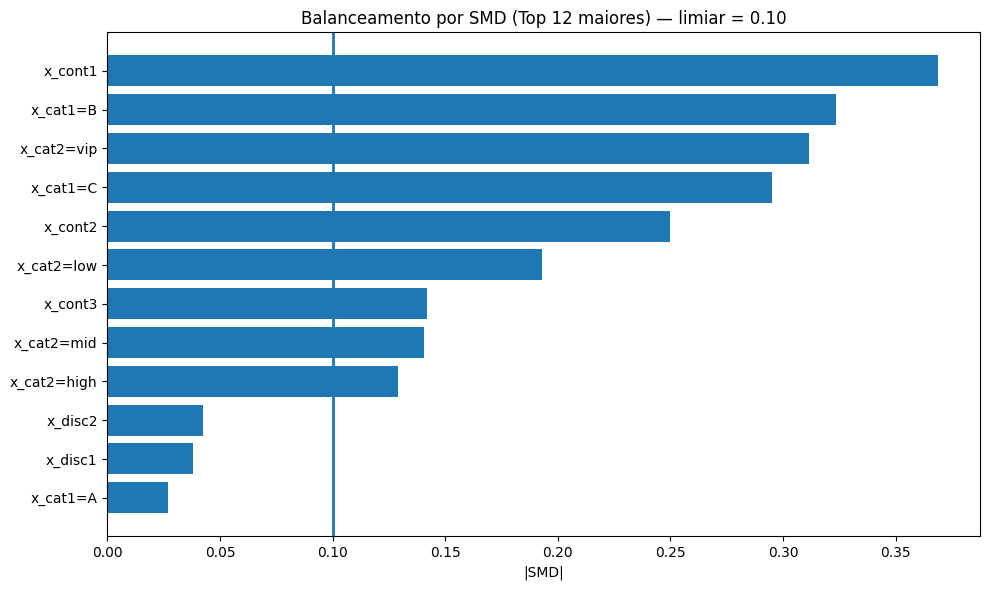

In [14]:
smd_df = calcular_smd_por_variavel(
    df,
    treat_col="tratamento",
    cols=["x_cont1","x_cont2","x_cont3","x_disc1","x_disc2","x_cat1","x_cat2"],
    threshold=0.10,
    plot=True
)

In [15]:
print(smd_df.to_string(index=False))

variavel nivel             tipo       smd  abs_smd  media_trat  media_ctrl  prop_trat  prop_ctrl  balanceado(|SMD|<limiar)
 x_cont1  None         numerica  0.369004 0.369004    0.186914   -0.196177        NaN        NaN                     False
  x_cat1     B categorica_dummy  0.323407 0.323407         NaN         NaN   0.278854   0.148040                     False
  x_cat2   vip categorica_dummy  0.311674 0.311674         NaN         NaN   0.154144   0.059099                     False
  x_cat1     C categorica_dummy -0.295035 0.295035         NaN         NaN   0.344694   0.488590                     False
 x_cont2  None         numerica  0.249970 0.249970    0.164779   -0.182941        NaN        NaN                     False
  x_cat2   low categorica_dummy -0.193158 0.193158         NaN         NaN   0.202943   0.285547                     False
 x_cont3  None         numerica  0.141984 0.141984    0.698946    0.548317        NaN        NaN                     False
  x_cat2   mid c

# Calculando propensity score


=== Propensity Score: resumo e suporte comum ===
Treated   PS min/max: 0.1682 / 0.9042
Control   PS min/max: 0.1632 / 0.8715
Common support interval: [0.1682, 0.8715]
% tratados fora do common support: 0.23%
% controles fora do common support: 0.12%


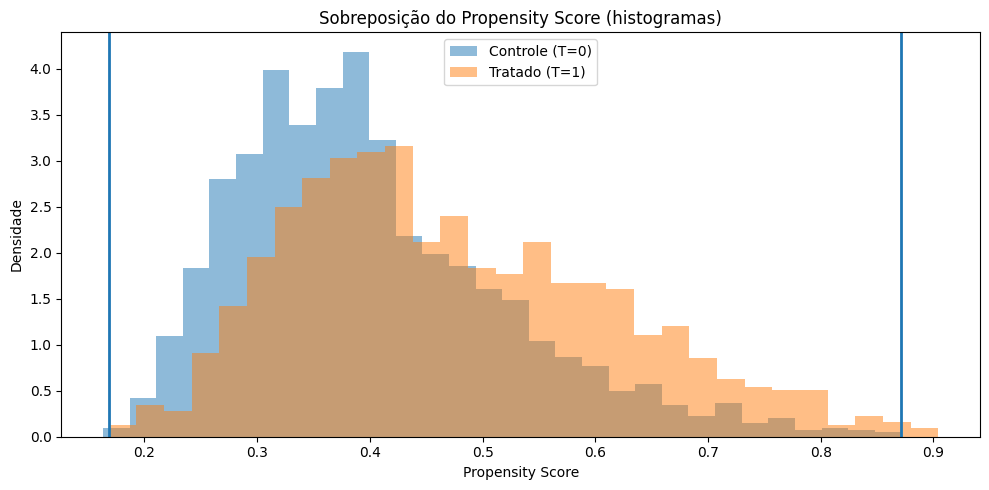

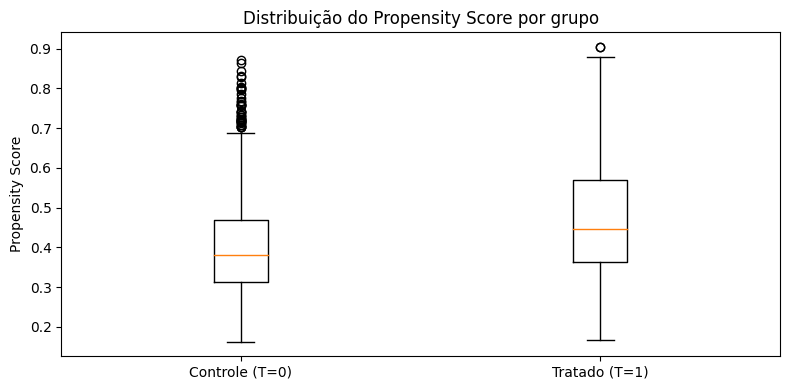


Overlap coefficient (interseção de densidades por hist): 0.777 (0..1)


In [16]:
df_ps = estimar_propensity_score(df)
metrics = avaliar_sobreposicao(df_ps)

In [17]:
# Trimming por common support
df_trim_cs, info_trim = aplicar_trimming_overlap_ps(
    df_ps,
    ps_range=(0.1, 0.9),
    intersect_common_support=True,
)


=== Trimming por Overlap (PS range) ===
ps_range alvo: [0.1000, 0.9000]
common support empírico: [0.1682, 0.8715]
intervalo final mantido: [0.1682, 0.8715]
Antes: 3000 | Depois: 2995 | Removidas: 5 (0.17%)
Tratados: 1291 -> 1288 (removidos 3)
Controles: 1709 -> 1707 (removidos 2)



=== Propensity Score: resumo e suporte comum ===
Treated   PS min/max: 0.1682 / 0.8699
Control   PS min/max: 0.1815 / 0.8715
Common support interval: [0.1815, 0.8699]
% tratados fora do common support: 0.23%
% controles fora do common support: 0.06%


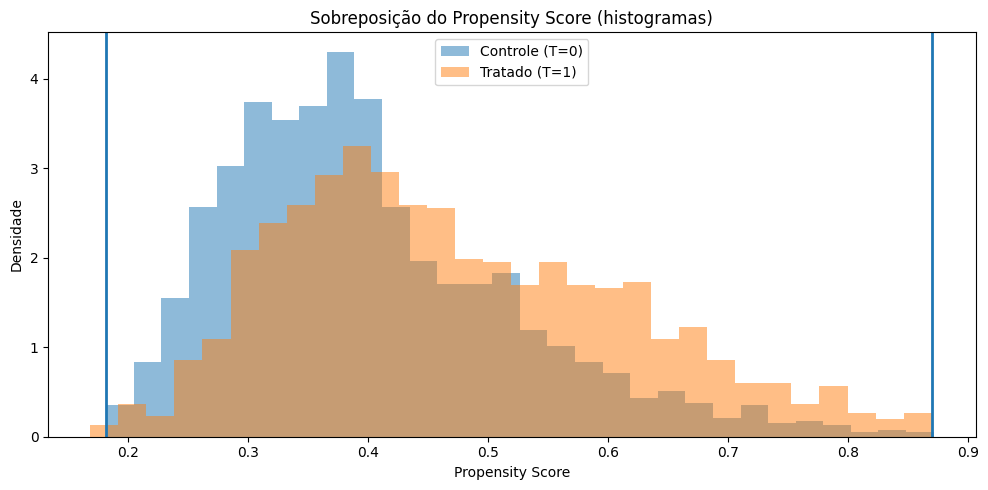

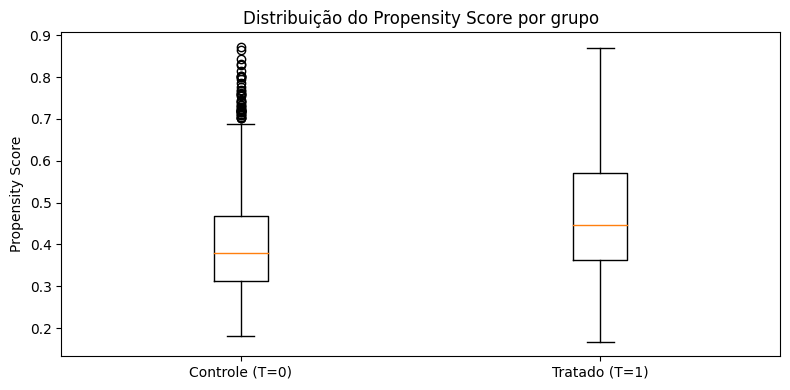


Overlap coefficient (interseção de densidades por hist): 0.778 (0..1)


{'common_support': (0.1814784013166844, 0.869938365436244),
 'pct_out_support_treated': 0.002329192546583851,
 'pct_out_support_control': 0.0005858230814294083,
 'overlap_coeff': 0.7783496526906015}

In [18]:
# Reavaliar overlap depois do trimming:
avaliar_sobreposicao(df_trim_cs)

In [19]:
df_trim_cs.head()

,tratamento,desfecho,x_cont1,x_cont2,x_cont3,x_disc1,x_disc2,x_cat1,x_cat2,propensity_score
0,0,2.200410,0.359139,0.885188,0.226312,2,7,C,mid,0.267177
1,0,1.584927,-1.271616,-1.151824,1.521553,2,3,C,mid,0.336886
2,1,6.631998,0.900214,1.520070,0.747451,1,7,B,vip,0.659731
3,1,4.584556,0.802387,-0.142615,0.830919,2,3,C,mid,0.501057
4,1,2.558266,-2.161534,-2.655398,1.534139,0,1,A,low,0.399051


# Decidindo a modalidade do matching

C:\Users\gcabr\AppData\Local\Temp\ipykernel_18648\3869230650.py:62: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  or pd.api.types.is_categorical_dtype(s)
C:\Users\gcabr\AppData\Local\Temp\ipykernel_18648\3869230650.py:62: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  or pd.api.types.is_categorical_dtype(s)
C:\Users\gcabr\AppData\Local\Temp\ipykernel_18648\3869230650.py:62: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  or pd.api.types.is_categorical_dtype(s)
C:\Users\gcabr\AppData\Local\Temp\ipykernel_18648\3869230650.py:62: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  or pd.api.ty

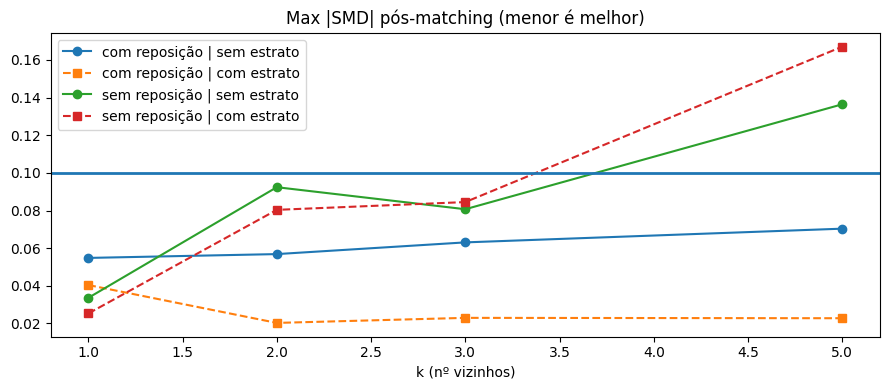

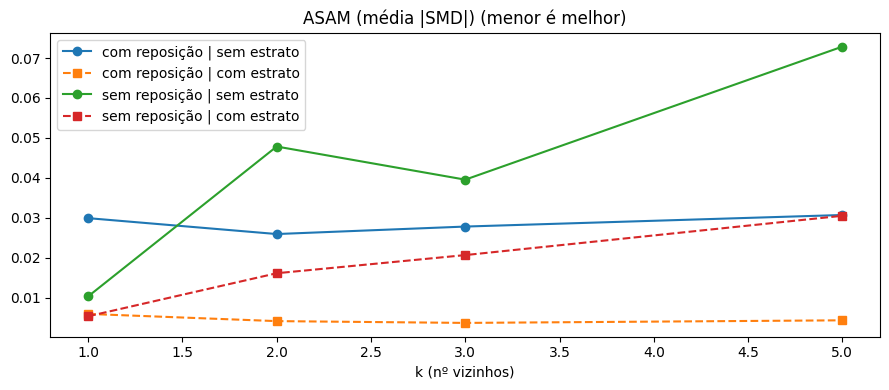

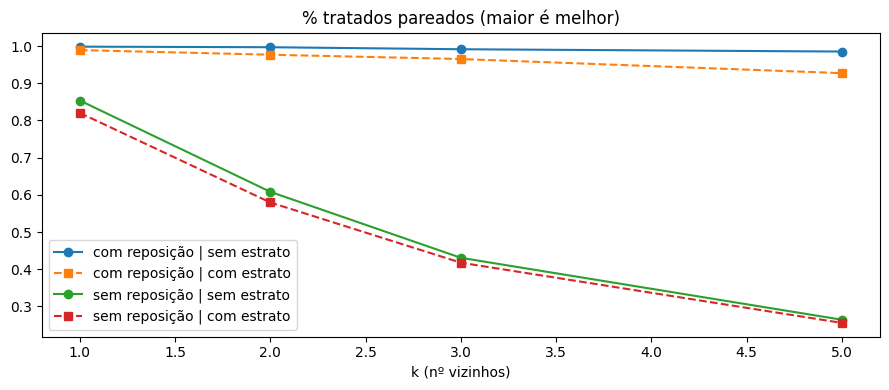

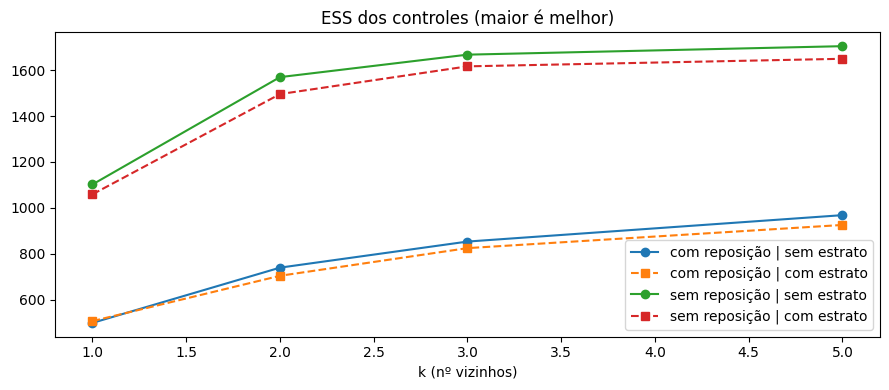

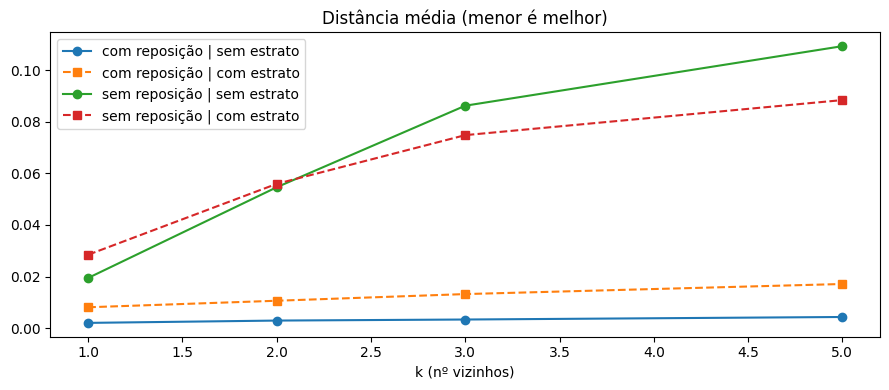

,k,with_replacement,with_strata,strata_cols,treated_match_rate,treated_matched,total_pairs,unique_controls,mean_distance,asam,...,ess_controls,rubin_B,rubin_R,n_strata_treated,n_strata_control,n_strata_overlap,treated_no_control_same_stratum,treated_controls_lt_k_same_stratum,strata_coverage_rate_any_control,strata_coverage_rate_control_ge_k
9,2,True,True,"x_cat1,x_cat2",0.976762,1261,2522,1133,0.010630,0.004149,...,703.593363,0.004612,1.003905,12.0,12.0,12.0,0.0,0.0,1.0,1.0
11,5,True,True,"x_cat1,x_cat2",0.927188,1197,5985,1519,0.017120,0.004350,...,925.324197,0.007188,1.003783,12.0,12.0,12.0,0.0,0.0,1.0,1.0
10,3,True,True,"x_cat1,x_cat2",0.965143,1246,3738,1328,0.013214,0.003701,...,824.247522,0.061893,1.005071,12.0,12.0,12.0,0.0,0.0,1.0,1.0
12,1,False,True,"x_cat1,x_cat2",0.820294,1059,1059,1059,0.028467,0.005364,...,1059.000000,4.820126,0.903718,12.0,12.0,12.0,0.0,0.0,1.0,1.0
4,1,False,False,None,0.853602,1102,1102,1102,0.019469,0.010349,...,1102.000000,3.681770,0.894919,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1,True,True,"x_cat1,x_cat2",0.989156,1277,1277,753,0.008102,0.005953,...,505.966181,0.121596,1.003968,12.0,12.0,12.0,0.0,0.0,1.0,1.0
0,1,True,False,None,0.998451,1289,1289,750,0.002046,0.029922,...,498.207196,0.016181,1.000529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,True,False,None,0.996902,1287,2574,1149,0.002945,0.025945,...,739.120482,0.023816,1.001568,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,True,False,None,0.991479,1280,3840,1350,0.003350,0.027818,...,852.839792,0.033845,1.001959,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5,True,False,None,0.985283,1272,6360,1536,0.004331,0.030713,...,968.064331,0.016768,1.001454,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
covs = ["x_cont1","x_cont2","x_cont3","x_disc1","x_disc2","x_cat1","x_cat2"]
panel = matching_grid_search(
    df_ps,
    covariates=covs,
    ks=(1,2,3,5),
    replacement_options=(True, False),
    smd_threshold=0.10,
    strata_cols=["x_cat1", "x_cat2"],  
    compare_strata=True,
    caliper=0.2,
    use_logit=True,
    require_full_match=True
)
plot_tradeoffs(panel, smd_threshold=0.10)
display(panel.head(20))

# Executando o matching

In [21]:
pairs, info = propensity_score_matching(df_trim_cs, k=2, with_replacement=True, 
                                        caliper=0.2, use_logit=True,require_full_match=False,
                                       strata_cols=['x_cat1','x_cat2'])
print(info)

df_matched = construir_base_matched_com_pesos_ATT(
    df_trim_cs, pairs, k=2,
    normalize_by_treated=True)

{'n_treated': 1288, 'n_control': 1707, 'k_requested': 2, 'with_replacement': True, 'use_logit': True, 'caliper_abs': 0.12288525031148008, 'require_full_match': False, 'treated_matched': 1275, 'treated_match_rate': 0.9899068322981367, 'avg_neighbors_kept': 1.988235294117647, 'total_pairs': 2535, 'strata_cols': 'x_cat1,x_cat2', 'n_strata_treated': 12, 'n_strata_control': 12, 'n_strata_overlap': 12, 'treated_no_control_same_stratum': 0, 'treated_controls_lt_k_same_stratum': 0, 'strata_coverage_rate_any_control': 1.0, 'strata_coverage_rate_control_ge_k': 1.0}


In [22]:
df_matched.head()

,tratamento,desfecho,x_cont1,x_cont2,x_cont3,x_disc1,x_disc2,x_cat1,x_cat2,propensity_score,peso
51,1,5.482760,0.506088,0.288053,-0.438158,0,6,A,high,0.426194,1.0
90,1,4.225063,0.456808,1.285689,0.199077,1,6,A,high,0.400981,1.0
124,1,3.114256,0.586197,0.838459,-0.634619,2,5,A,high,0.474451,1.0
184,1,2.917386,0.425550,1.368788,-0.578547,1,6,A,high,0.363493,1.0
193,1,4.689210,1.430303,1.529053,1.224027,0,5,A,high,0.539900,1.0


In [23]:
df_matched['tratamento'].value_counts()

tratamento
1    1275
0    1136
Name: count, dtype: int64

In [24]:
df_matched['peso'].value_counts()

peso
1.0    1544
0.5     519
1.5     165
2.0      81
2.5      37
3.0      27
3.5      16
4.0       7
4.5       5
5.0       4
5.5       3
7.0       1
7.5       1
6.0       1
Name: count, dtype: int64

In [25]:
pairs

,treated_id,control_id,distance,rank
0,51,2424,0.007016,1
1,51,262,0.012441,2
2,90,2295,0.000332,1
3,90,1410,0.000446,2
4,124,1397,0.004541,1
...,...,...,...,...
2530,2619,991,0.027003,2
2531,2896,2329,0.016283,1
2532,2896,2030,0.032203,2
2533,2933,2360,0.046505,1


# SMD pós-metodo

variavel nivel       smd  abs_smd  ok(|SMD|<limiar)
 x_cont1  None  0.020851 0.020851              True
 x_disc1  None  0.020473 0.020473              True
 x_disc2  None -0.008772 0.008772              True
 x_cont3  None  0.005775 0.005775              True
 x_cont2  None -0.000782 0.000782              True
  x_cat1     A  0.000000 0.000000              True
  x_cat1     B  0.000000 0.000000              True
  x_cat1     C  0.000000 0.000000              True
  x_cat2  high  0.000000 0.000000              True
  x_cat2   low  0.000000 0.000000              True
  x_cat2   mid  0.000000 0.000000              True
  x_cat2   vip  0.000000 0.000000              True


C:\Users\gcabr\AppData\Local\Temp\ipykernel_18648\3321247187.py:39: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  or pd.api.types.is_categorical_dtype(s)


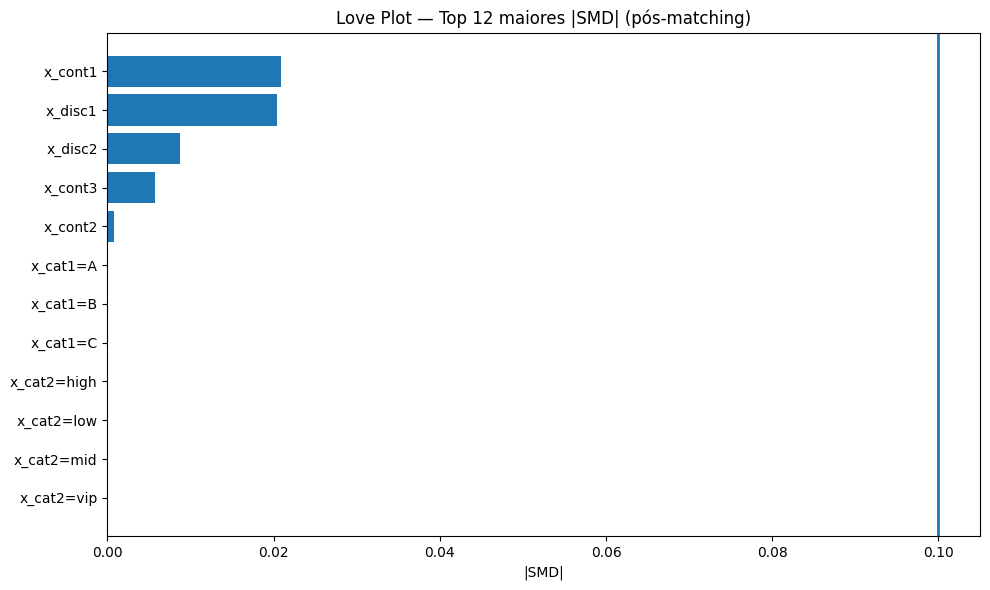

In [26]:
smd_post = smd_table_matched(df_matched, threshold=0.10)
print(smd_post.head(30).to_string(index=False))
love_plot(smd_post, threshold=0.10)

# ATT + Bootstrap (diferenca ponderada entre os grupos)

In [27]:
# 1) ATT pontual
att_hat, diffs, diag_pairs = att_from_pairs(
    df_matched=df_matched,
    pairs=pairs,
    # Se treated_id/control_id forem o índice do df_matched, pode deixar assim:
    id_col="id",
    outcome_col="desfecho",
    treated_id_col="treated_id",
    control_id_col="control_id",
    distance_col="distance",
    weight_scheme="equal"   # padrão para 1:k
)

print("ATT (pontual):", att_hat)
print("N tratados pareados:", len(diffs))

# 2) IC por bootstrap
att_hat, ci_low, ci_high, boot_dist = bootstrap_att_ci(
    diffs,
    n_boot=2000,
    alpha=0.05,
    random_state=42
)

print(f"ATT: {att_hat:.6f}")
print(f"IC 95% (percentil): [{ci_low:.6f}, {ci_high:.6f}]")

ATT (pontual): 1.5532709030868252
N tratados pareados: 1275
ATT: 1.553271
IC 95% (percentil): [1.486952, 1.623202]


# WLS - V1

In [28]:
df = df_matched.copy()

# (opcional, mas recomendado) garantir que categóricas sejam tratadas como categóricas
df["x_cat1"] = df["x_cat1"].astype("category")
df["x_cat2"] = df["x_cat2"].astype("category")

formula = """
desfecho ~ tratamento
        + x_cont1 + x_cont2 + x_cont3
        + x_disc1 + x_disc2
        + C(x_cat1) + C(x_cat2)
"""

res = smf.wls(formula, data=df, weights=df["peso"]).fit(cov_type="HC3")
print(res.summary())

                            WLS Regression Results                            
Dep. Variable:               desfecho   R-squared:                       0.578
Model:                            WLS   Adj. R-squared:                  0.576
Method:                 Least Squares   F-statistic:                     264.0
Date:                Sat, 31 Jan 2026   Prob (F-statistic):               0.00
Time:                        23:36:00   Log-Likelihood:                -3654.9
No. Observations:                2411   AIC:                             7334.
Df Residuals:                    2399   BIC:                             7403.
Df Model:                          11                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            2.5241      0.134  

# WLS - V2 (efeito fixo no pareamento)

In [29]:
# ---------------------------
# 0) Lookup de unidades
# ---------------------------
df = df_matched.copy()
df["id"] = df.index  # se você já tiver coluna id, use df["id"] = df["id"]

# ---------------------------
# 1) Tratados (1 linha por tratado_id)
# ---------------------------
treated_ids = pairs["treated_id"].unique()

t = df[df["id"].isin(treated_ids)].copy()
t["match_set"] = t["id"]      # cada tratado define o conjunto
t["unit_id"]   = t["id"]      # id original da unidade
t["w"]         = 1.0          # peso do tratado dentro do set

# IMPORTANTÍSSIMO: garantir papel "tratado" = 1 no long (mesmo que no df original tenha algo estranho)
t["tratamento"] = 1

# ---------------------------
# 2) Controles (1 linha por par: treated_id x control_id)
# ---------------------------
c = pairs[["treated_id", "control_id"]].merge(
    df,
    left_on="control_id",
    right_on="id",
    how="left",
    validate="m:1"
)

# checagem rápida: se algum control_id não está no df
if c["id"].isna().any():
    bad = c[c["id"].isna()][["treated_id","control_id"]].head(10)
    raise ValueError("Tem control_id no pairs que não existe no df_matched. Exemplo:\n" + bad.to_string(index=False))

c["match_set"] = c["treated_id"]
c["unit_id"]   = c["control_id"]

# peso por tratado: cada tratado distribui 1 igualmente entre seus m_i controles
m_i = c.groupby("treated_id")["control_id"].transform("count").astype(float)
c["w"] = 1.0 / m_i

# IMPORTANTÍSSIMO: garantir papel "controle" = 0 no long
c["tratamento"] = 0

# (opcional) remover colunas do pairs que não quer carregar
c = c.drop(columns=["treated_id", "control_id"], errors="ignore")

# ---------------------------
# 3) Base long final
# ---------------------------
long_df = pd.concat([t, c], ignore_index=True)

# sanity check: soma dos pesos dos controles por tratado ~ 1
check = long_df[long_df["tratamento"] == 0].groupby("match_set")["w"].sum()
print("Min/Max soma pesos controles por tratado:", check.min(), check.max())

Min/Max soma pesos controles por tratado: 1.0 1.0


In [30]:
formula = """
desfecho ~ tratamento
        + x_cont1 + x_cont2 + x_cont3
        + x_disc1 + x_disc2
        + C(x_cat1) + C(x_cat2)
        + C(match_set)
"""

res = smf.wls(formula, data=long_df, weights=long_df["w"]).fit(
    cov_type="cluster",
    cov_kwds={"groups": long_df["match_set"]}  # cluster por tratado (simples e bem coerente)
)

tab = pd.DataFrame({
    "coef": res.params,
    "se": res.bse,
    "t": res.tvalues,
    "p": res.pvalues
})

# esconder os efeitos fixos do match_set (mas manter todo o resto, incluindo interações)
mask = ~tab.index.str.contains(r"C\(match_set\)")
tab2 = tab[mask].copy()
tab2["abs_t"] = tab2["t"].abs()

print(tab2.sort_values("abs_t", ascending=False).head(40))

                      coef        se          t              p      abs_t
tratamento        1.527247  0.044717  34.153522  1.185498e-255  34.153522
C(x_cat1)[T.C]   -0.385838  0.024762 -15.581690   9.695653e-55  15.581690
C(x_cat2)[T.vip]  1.378256  0.124804  11.043376   2.359970e-28  11.043376
Intercept         2.150695  0.203186  10.584846   3.503559e-26  10.584846
x_disc1           0.159947  0.024776   6.455855   1.076096e-10   6.455855
C(x_cat2)[T.mid] -0.337663  0.052755  -6.400597   1.547707e-10   6.400597
x_cont3           0.243456  0.051568   4.721102   2.345708e-06   4.721102
C(x_cat1)[T.B]    0.186912  0.054719   3.415834   6.358710e-04   3.415834
x_cont1           0.867295  0.275219   3.151296   1.625478e-03   3.151296
x_cont2          -0.357575  0.178478  -2.003466   4.512724e-02   2.003466
C(x_cat2)[T.low] -0.208022  0.124827  -1.666476   9.561858e-02   1.666476
x_disc2          -0.052008  0.050313  -1.033682   3.012847e-01   1.033682
